Libraries

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from adjustText import adjust_text
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from scipy.stats import spearmanr

Paths

In [153]:
QUERIES_DIR = "data/results/queries"
MODELS_DIR = "data/results/models"

# Join Results

## Queries

In [154]:
queries_rows = []

for file_name in os.listdir(QUERIES_DIR):

    if file_name.endswith(".json"):

        file_path = os.path.join(QUERIES_DIR, file_name)

        with open(file_path, "r") as f:
            data = json.load(f)

        for run in data.get("runs", []):

            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),

                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }

            for metric in run.get("metrics", []):

                row = {
                    **base_info,

                    "query_description": metric.get("Query Description"),
                    "api_time_s": metric.get("API Time (s)"),
                    "sql_time_s": metric.get("SQL Time (s)"),
                    "time_delta": metric.get("Time Delta (SQL - API)")
                }

                queries_rows.append(row)

df_queries = pd.DataFrame(queries_rows)

## Models

In [155]:
models_rows = []

for file_name in os.listdir(MODELS_DIR):

    if file_name.endswith(".json"):

        file_path = os.path.join(MODELS_DIR, file_name)

        with open(file_path, "r") as f:
            data = json.load(f)

        for run in data.get("runs", []):

            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),

                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }

            for result in run.get("model_results", []):

                metrics = result.get("metrics", {})

                row = {
                    **base_info,

                    "model_name": result.get("model_name"),
                    "target": result.get("target"),
                    "task_type": result.get("task_type"),

                    "rmse": metrics.get("rmse"),
                    "r2": metrics.get("r2"),
                    "mae": metrics.get("mae"),
                    "mse": metrics.get("mse"),

                    "execution_time_seconds": result.get("execution_time_seconds")
                }

                models_rows.append(row)

df_models = pd.DataFrame(models_rows)

## Preview

In [156]:
print("\n==============================")
print("QUERIES DATAFRAME")
print("==============================")
print(df_queries.head())

print("\nShape:", df_queries.shape)

print("\n==============================")
print("MODELS DATAFRAME")
print("==============================")
print(df_models.head())

print("\nShape:", df_models.shape)


QUERIES DATAFRAME
             timestamp spark_mode  executor_instances  executor_cores  \
0  2026-05-19 21:49:43   baseline                   2               1   
1  2026-05-19 21:49:43   baseline                   2               1   
2  2026-05-19 21:49:43   baseline                   2               1   
3  2026-05-19 21:49:43   baseline                   2               1   
4  2026-05-19 21:49:43   baseline                   2               1   

  executor_memory  shuffle_partitions  adaptive  \
0              3g                  50     False   
1              3g                  50     False   
2              3g                  50     False   
3              3g                  50     False   
4              3g                  50     False   

                         query_description  api_time_s  sql_time_s  time_delta  
0  Q1.1: Borough Revenue vs Tip Percentage     7.09525      8.6047    -91.4260  
1            Q1.2: Tip Paradox by Distance     6.04890      5.5679     -0

In [157]:
df_queries

,timestamp,spark_mode,executor_instances,executor_cores,executor_memory,shuffle_partitions,adaptive,query_description,api_time_s,sql_time_s,time_delta
0,2026-05-19 21:49:43,baseline,2,1,3g,50,False,Q1.1: Borough Revenue vs Tip Percentage,7.09525,8.6047,-91.4260
1,2026-05-19 21:49:43,baseline,2,1,3g,50,False,Q1.2: Tip Paradox by Distance,6.04890,5.5679,-0.4810
2,2026-05-19 21:49:43,baseline,2,1,3g,50,False,Q1.3: Revenue Composition,1.51940,1.1499,-0.3695
3,2026-05-19 21:49:43,baseline,2,1,3g,50,False,Q1.4: Payment Method Impact,4.86770,4.3173,-0.5504
4,2026-05-19 21:49:43,baseline,2,1,3g,50,False,Q1.5: Passenger Count Impact,5.22690,4.8360,-0.3909
...,...,...,...,...,...,...,...,...,...,...,...
894,2026-05-19 17:45:40,cpu_heavy,3,3,3g,150,True,Q4.9: Monthly Evolution of Average Revenue by ...,1.93530,1.1644,-0.7710
895,2026-05-19 17:45:40,cpu_heavy,3,3,3g,150,True,Q5.1: Hourly Analysis of Taxi Operations,2.17090,1.5224,-0.6485
896,2026-05-19 17:45:40,cpu_heavy,3,3,3g,150,True,Q5.2: Analysis of Non-Revenue Trips and Disput...,1.60220,1.4541,-0.1482
897,2026-05-19 17:45:40,cpu_heavy,3,3,3g,150,True,Q5.3: The Inverse Relationship Between Revenue...,1.67810,1.4429,-0.2352


In [158]:
COLOR_API = "#faba71"
COLOR_SQL = "#a1301c"
color_palette = [COLOR_API, COLOR_SQL]

BG_COLOR = "#ffffff"

SCENARIO_COLORS = {
    'aqe_only': '#457b9d',
    'balanced': '#f4a261',
    'baseline': '#2a9d8f',
    'cpu_heavy': '#e76f51',
    'high_parallelism': '#9b5de5',
    'low_overhead': '#8d99ae',
    'memory_optimized': '#f15bb5',
    'stress_test': '#00b4d8'
}

MODEL_COLORS = {
    'RandomForest': "#0d67a3",
    'GeneralizedLinearModel': "#d1495b",
    'LinearRegression': "#11b1ce",
    'DecisionTree': "#edae49",
    'GBT': "#84e4b1"
}

C_POS = "#F08080"
C_NEG = "#7CC97C"

# Scenarios Config

In [159]:
SCENARIO_ORDER = [
    "baseline", "balanced", "high_parallelism", "memory_optimized",
    "stress_test", "low_overhead", "aqe_only", "cpu_heavy"
]

df_queries["total_cores"] = df_queries["executor_instances"] * df_queries["executor_cores"]
df_models["total_cores"] = df_models["executor_instances"] * df_models["executor_cores"]

# Filter to only scenarios actually present in our results
present_scenarios = [s for s in SCENARIO_ORDER if s in df_queries["spark_mode"].unique()]
present_scenarios_models = [s for s in SCENARIO_ORDER if s in df_models["spark_mode"].unique()]

scenario_cfg = (
    df_queries.dropna(subset=["spark_mode"])
              .groupby("spark_mode")
              .agg(executor_instances=("executor_instances", "first"),
                   executor_cores=("executor_cores", "first"),
                   executor_memory=("executor_memory", "first"),
                   shuffle_partitions=("shuffle_partitions", "first"),
                   adaptive=("adaptive", "first"),
                   total_cores=("total_cores", "first"))
              .reindex(present_scenarios)
)
scenario_cfg

,executor_instances,executor_cores,executor_memory,shuffle_partitions,adaptive,total_cores
spark_mode,,,,,,
baseline,2,1,3g,50,False,2
balanced,2,2,4g,100,True,4
high_parallelism,3,2,4g,150,True,6
memory_optimized,2,1,6g,100,True,2
stress_test,4,2,3g,200,True,8
low_overhead,2,2,4g,25,False,4
aqe_only,2,1,3g,50,True,2
cpu_heavy,3,3,3g,150,True,9


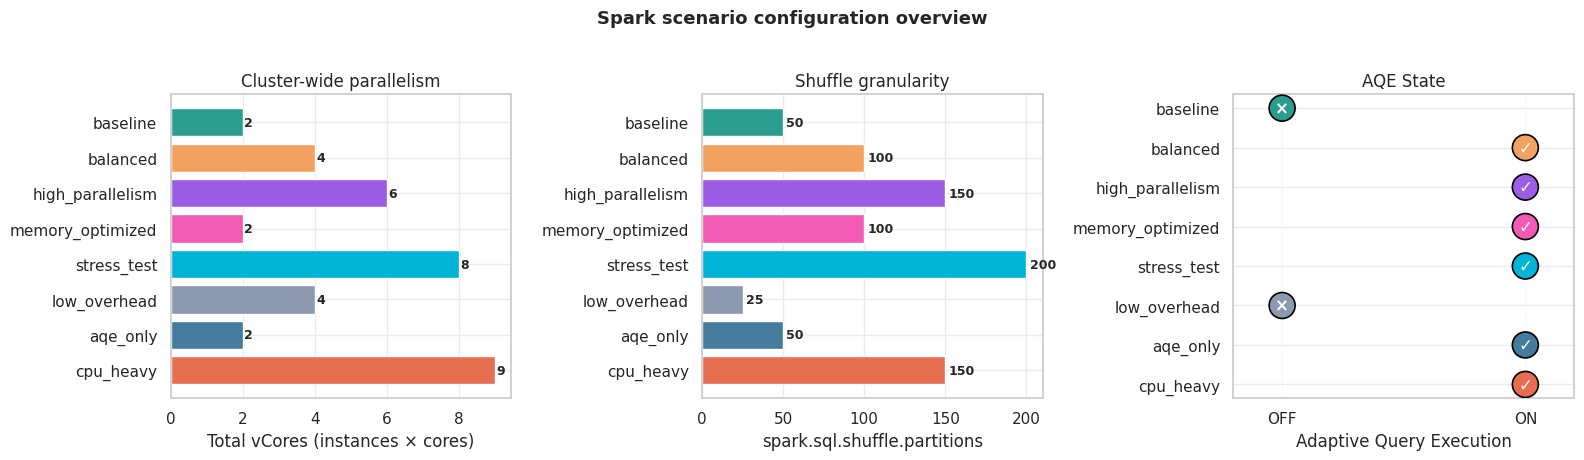

In [160]:
# Visualize the configuration space along its main axes
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
scenarios = scenario_cfg.index.tolist()
colors = [SCENARIO_COLORS[s] for s in scenarios]

axes[0].barh(scenarios, scenario_cfg["total_cores"], color=colors, edgecolor="white")
axes[0].set_xlabel("Total vCores (instances × cores)")
axes[0].set_title("Cluster-wide parallelism")
axes[0].invert_yaxis()
for i, v in enumerate(scenario_cfg["total_cores"]):
    axes[0].text(v + 0.05, i, str(int(v)), va="center", fontsize=9, fontweight="bold")

axes[1].barh(scenarios, scenario_cfg["shuffle_partitions"], color=colors, edgecolor="white")
axes[1].set_xlabel("spark.sql.shuffle.partitions")
axes[1].set_title("Shuffle granularity")
axes[1].invert_yaxis()
for i, v in enumerate(scenario_cfg["shuffle_partitions"]):
    axes[1].text(v + 2, i, str(int(v)), va="center", fontsize=9, fontweight="bold")

aqe_int = scenario_cfg["adaptive"].astype(int)

axes[2].scatter(aqe_int, scenarios, s=350, c=colors, edgecolors="black", linewidths=1.2, zorder=3)

axes[2].set_xlim(-0.2, 1.2)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["OFF", "ON"])
axes[2].set_xlabel("Adaptive Query Execution")
axes[2].set_title("AQE State")
axes[2].grid(axis='x', linestyle='--', alpha=0.3)

for i, v in enumerate(aqe_int):
    axes[2].text(
        v,
        i,
        "✓" if v == 1 else "×",
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        color='white'
    )

axes[2].invert_yaxis()

plt.suptitle("Spark scenario configuration overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


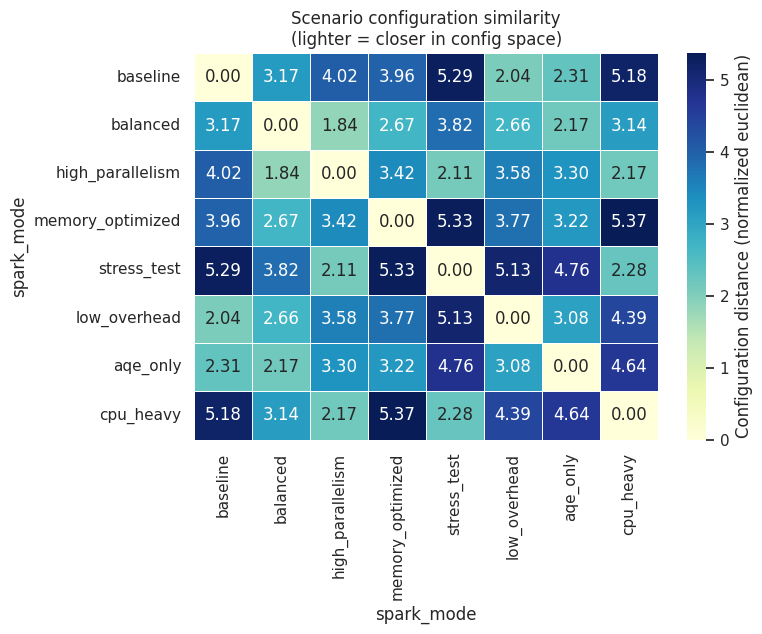


Closest pair: balanced ↔ high_parallelism (distance = 1.838)
Most distinct pair: memory_optimized ↔ cpu_heavy (distance = 5.367)


In [161]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

# Build a numeric feature matrix from the configuration
config_features = scenario_cfg.copy()
config_features["adaptive"] = config_features["adaptive"].astype(int)
config_features["memory_gb"] = (
    config_features["executor_memory"]
    .str.replace("g", "", regex=False).astype(float)
)

feature_cols = ["executor_instances", "executor_cores", "memory_gb",
                "shuffle_partitions", "adaptive", "total_cores"]

# Z-score normalize so each feature contributes equally
X = config_features[feature_cols].values.astype(float)
X_norm = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-9)

dist_matrix = squareform(pdist(X_norm, metric="euclidean"))
dist_df = pd.DataFrame(dist_matrix, index=config_features.index, columns=config_features.index)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(dist_df, annot=True, fmt=".2f", cmap="YlGnBu",
            cbar_kws={"label": "Configuration distance (normalized euclidean)"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Scenario configuration similarity\n(lighter = closer in config space)")
plt.tight_layout(); plt.show()

# Find the closest pair (excluding self-distance) and the most distinct
np.fill_diagonal(dist_matrix, np.inf)
i, j = np.unravel_index(dist_matrix.argmin(), dist_matrix.shape)
print(f"\nClosest pair: {config_features.index[i]} ↔ {config_features.index[j]} "
      f"(distance = {dist_matrix[i, j]:.3f})")

np.fill_diagonal(dist_matrix, -np.inf)
i, j = np.unravel_index(dist_matrix.argmax(), dist_matrix.shape)
print(f"Most distinct pair: {config_features.index[i]} ↔ {config_features.index[j]} "
      f"(distance = {dist_matrix[i, j]:.3f})")


# Queries Analysis

## ECDF Analysis

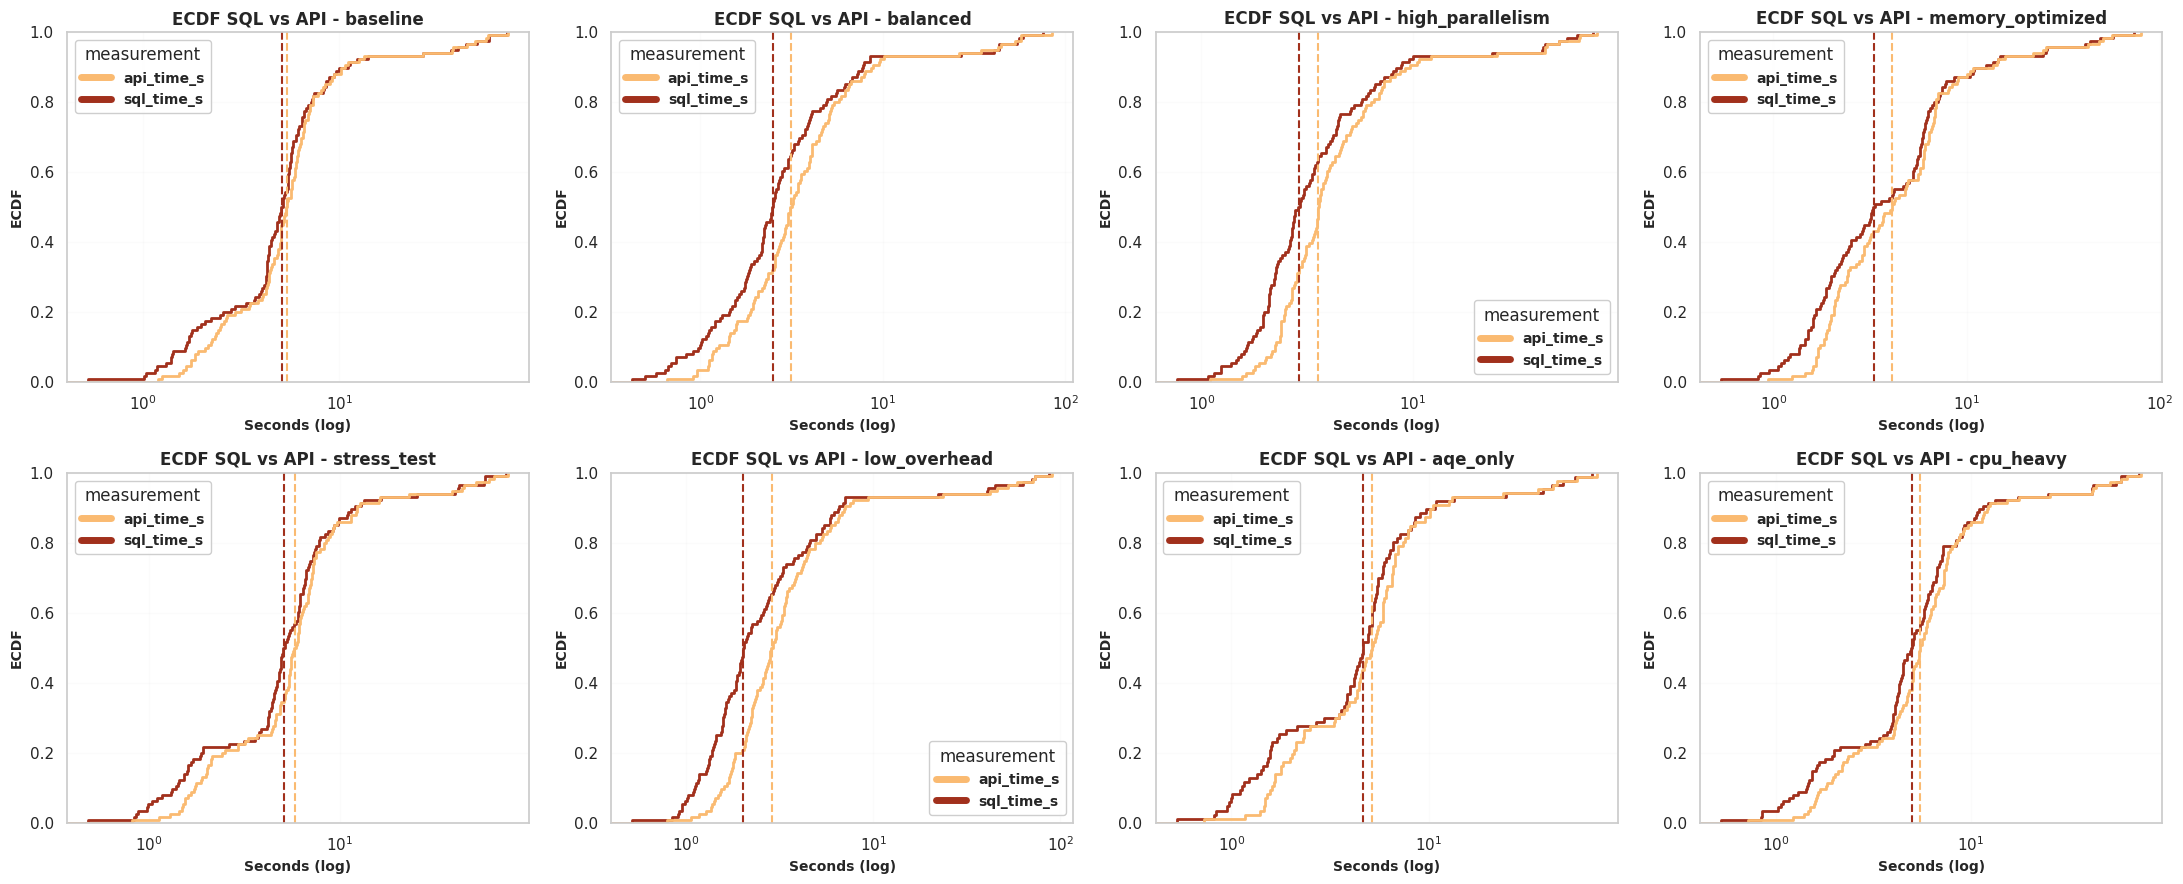

In [162]:
if df_queries.empty:
    raise ValueError("No query data was loaded.")

section_labels = {
    'Q1': 'Billing and Tips',
    'Q2': 'Geographic Patterns',
    'Q3': 'Temporal Dynamics',
    'Q4': 'Special Rates and Airports',
    'Q5': 'Efficiency and Operations'
}

section_order = list(section_labels.values())

qdf = df_queries.copy()

qdf['query_group'] = (
    qdf['query_description']
    .str.extract(r'^(Q\d)')[0]
)

qdf['section_name'] = (
    qdf['query_group']
    .map(section_labels)
)

qdf['section_name'] = pd.Categorical(
    qdf['section_name'],
    categories=section_order,
    ordered=True
)

qdf['time_delta_s'] = (
    qdf['sql_time_s'] -
    qdf['api_time_s']
)

spark_modes = (
    qdf['spark_mode']
    .dropna()
    .drop_duplicates()
    .tolist()
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(22, 9),
    squeeze=False
)

axes = axes.flatten()

for idx, spark_mode in enumerate(spark_modes[:8]):

    ax = axes[idx]

    mode_df = qdf[
        qdf['spark_mode'] == spark_mode
    ]

    if mode_df.empty:
        ax.axis("off")
        continue

    melt = mode_df.melt(
        id_vars=['section_name'],
        value_vars=['api_time_s', 'sql_time_s'],
        var_name='measurement',
        value_name='seconds'
    )

    sns.ecdfplot(
        data=melt,
        x='seconds',
        hue='measurement',
        ax=ax,
        linewidth=2,
        palette=[color_palette[0], color_palette[1]]
    )

    # thicker legend lines
    legend = ax.legend_

    for line in legend.get_lines():
        line.set_linewidth(5)

    # legend styling
    legend.get_frame().set_alpha(0.95)

    for text in legend.get_texts():
        text.set_fontsize(10)
        text.set_fontweight('bold')

    ax.set_xscale('log')

    ax.set_title(
        f'ECDF SQL vs API - {spark_mode}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Seconds (log)',
        fontsize=10,
        fontweight='bold'
    )

    ax.set_ylabel(
        'ECDF',
        fontsize=10,
        fontweight='bold'
    )

    ax.axvline(
        mode_df['api_time_s'].median(),
        color=color_palette[0],
        linestyle='--',
        linewidth=1.5
    )

    ax.axvline(
        mode_df['sql_time_s'].median(),
        color=color_palette[1],
        linestyle='--',
        linewidth=1.5
    )

    ax.grid(True, alpha=0.2)

for ax in axes[len(spark_modes):]:
    ax.axis("off")

plt.tight_layout()

plt.show()

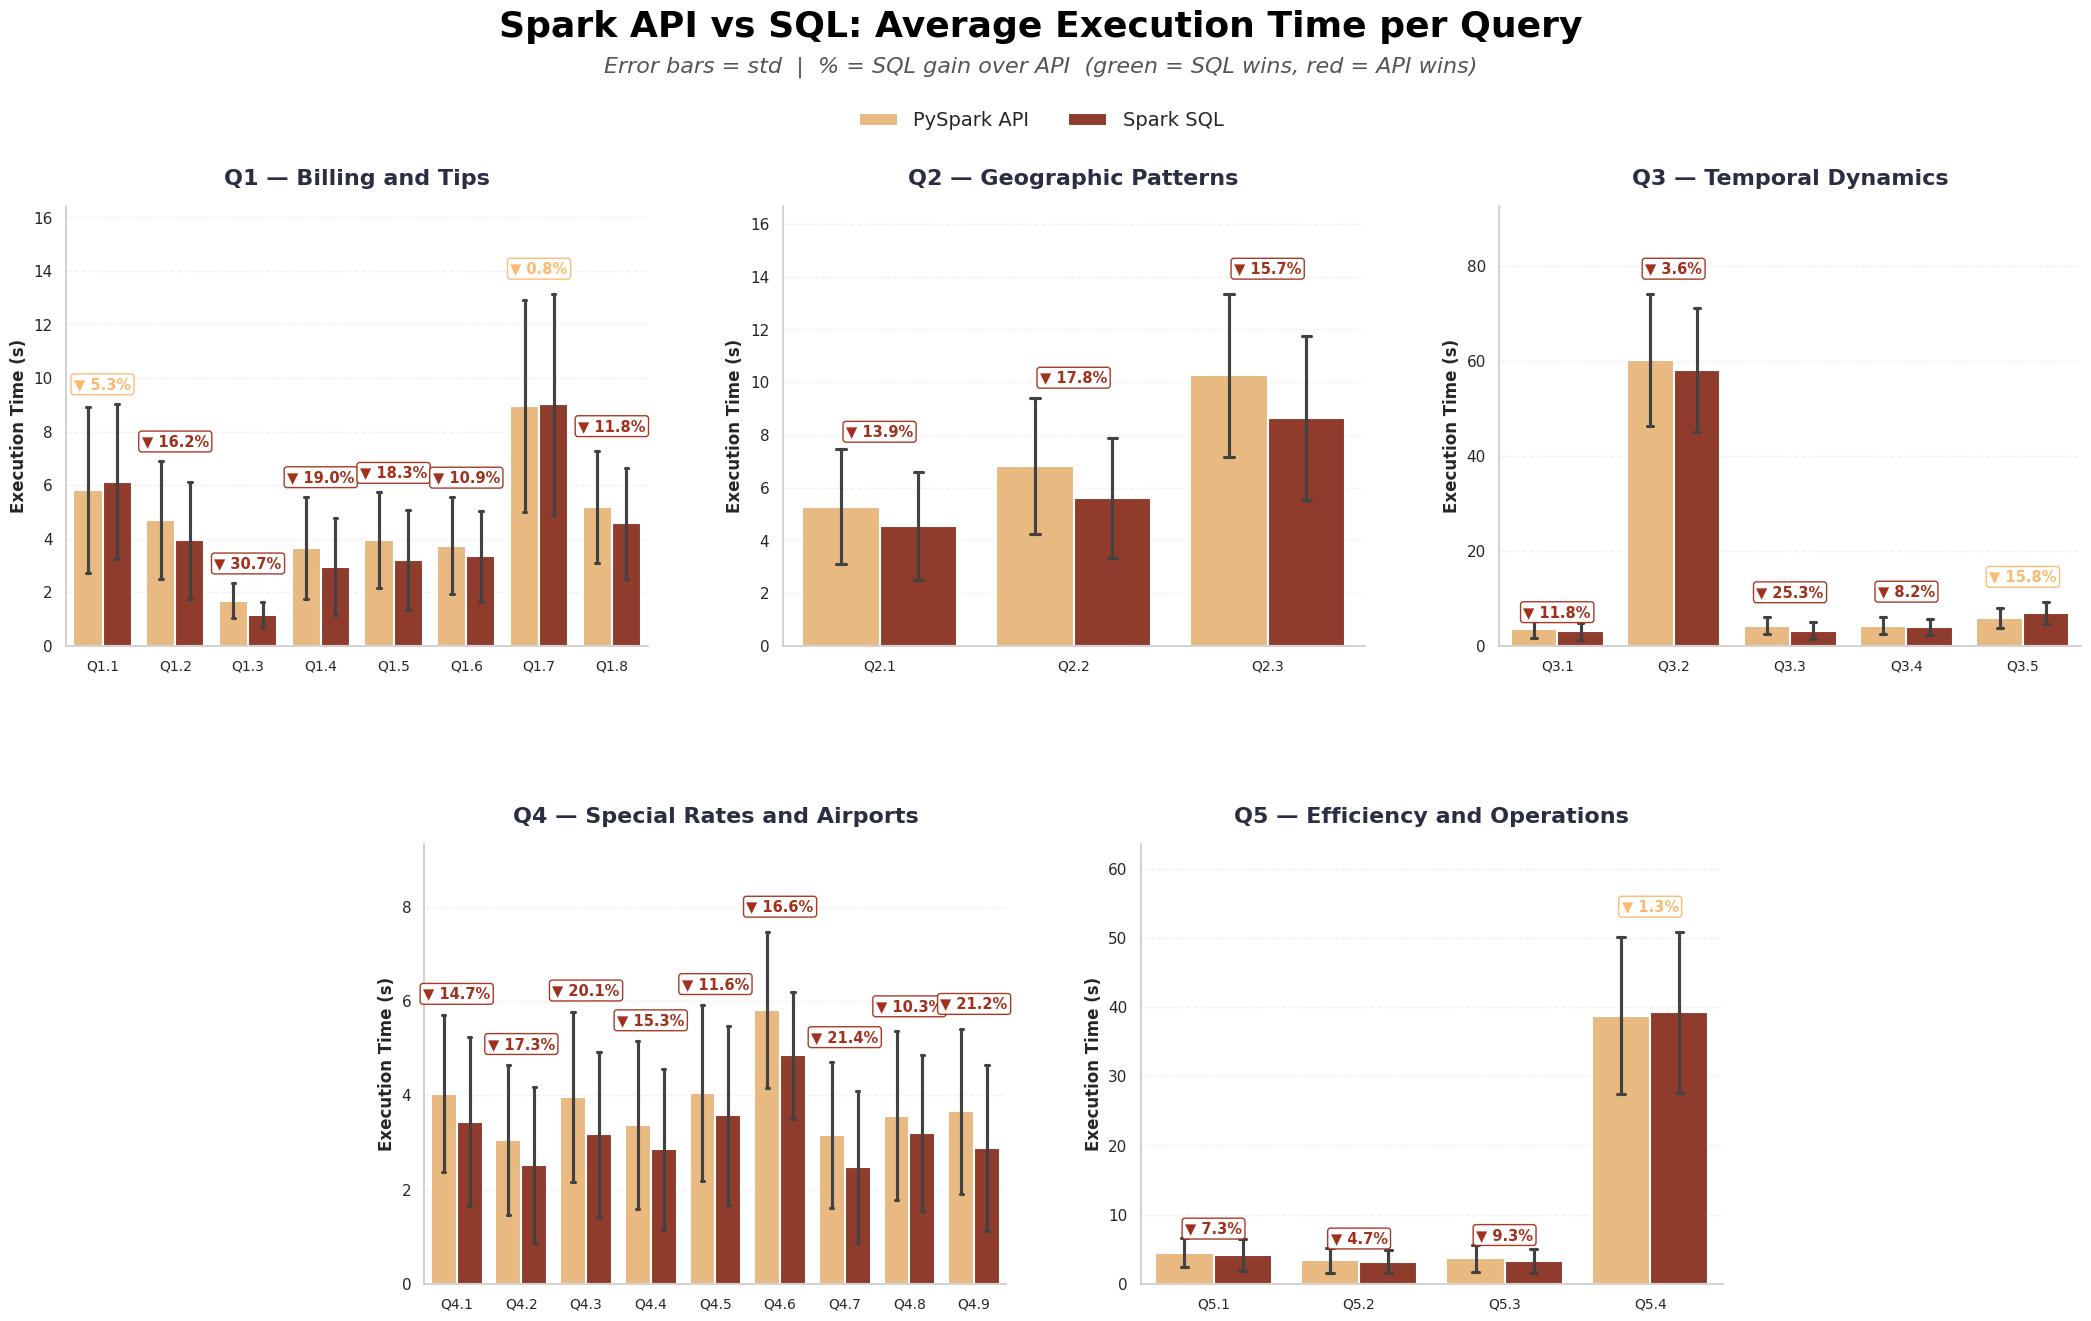

In [163]:
sns.set_theme(style="whitegrid")

CAT_NAMES = {
    "Q1": "Billing and Tips",
    "Q2": "Geographic Patterns",
    "Q3": "Temporal Dynamics",
    "Q4": "Special Rates and Airports",
    "Q5": "Efficiency and Operations",
}

df_queries['query_id'] = (
    df_queries['query_description']
    .apply(lambda x: x.split(':')[0].strip())
)

df_queries['section'] = (
    df_queries['query_id']
    .apply(lambda x: x.split('.')[0].strip())
)

sections = sorted(df_queries['section'].unique())

fig = plt.figure(figsize=(26, 14), facecolor=BG_COLOR)

fig.suptitle(
    "Spark API vs SQL: Average Execution Time per Query",
    fontsize=26,
    fontweight='900',
    color="#000000",
    y=1.02
)

fig.text(
    0.5,
    0.975,
    "Error bars = std  |  % = SQL gain over API  (green = SQL wins, red = API wins)",
    ha='center',
    fontsize=16,
    color='#555555',
    style='italic'
)

gs = gridspec.GridSpec(
    2,
    6,
    figure=fig,
    hspace=0.45,
    wspace=0.6
)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])

axes = [ax1, ax2, ax3, ax4, ax5]

for i, sec in enumerate(sections[:5]):

    ax = axes[i]

    df_sec = df_queries[
        df_queries['section'] == sec
    ].copy()

    query_order = sorted(
        df_sec['query_id'].unique()
    )

    df_melt = df_sec.melt(
        id_vars=['query_id'],
        value_vars=['api_time_s', 'sql_time_s'],
        var_name='method',
        value_name='time'
    )

    sns.barplot(
        data=df_melt,
        x='query_id',
        y='time',
        hue='method',
        order=query_order,
        palette={
            'api_time_s': COLOR_API,
            'sql_time_s': COLOR_SQL
        },
        edgecolor='white',
        linewidth=1.5,
        errorbar='sd',
        capsize=0.1,
        ax=ax
    )

    max_height_in_plot = 0

    for idx, q_id in enumerate(query_order):

        api_data = df_sec[
            df_sec['query_id'] == q_id
        ]['api_time_s']

        sql_data = df_sec[
            df_sec['query_id'] == q_id
        ]['sql_time_s']

        api_mean = api_data.mean()
        sql_mean = sql_data.mean()

        api_std = api_data.std()
        sql_std = sql_data.std()

        api_std = 0 if pd.isna(api_std) else api_std
        sql_std = 0 if pd.isna(sql_std) else sql_std

        api_top = api_mean + api_std
        sql_top = sql_mean + sql_std

        local_max = max(api_top, sql_top)

        max_height_in_plot = max(
            max_height_in_plot,
            local_max
        )

        if api_mean < sql_mean:

            win_color = COLOR_API

            pct_diff = (
                (sql_mean - api_mean)
                / sql_mean
            ) * 100

            label_text = f"▼ {pct_diff:.1f}%"

        else:

            win_color = COLOR_SQL

            pct_diff = (
                (api_mean - sql_mean)
                / api_mean
            ) * 100

            label_text = f"▼ {pct_diff:.1f}%"

        ax.text(
            idx,
            local_max + (max_height_in_plot * 0.05),
            label_text,
            ha='center',
            va='bottom',
            color=win_color,
            fontweight='900',
            fontsize=10.5,
            bbox=dict(
                facecolor='white',
                edgecolor=win_color,
                boxstyle='round,pad=0.2',
                alpha=0.95
            )
        )

    section_context = CAT_NAMES.get(sec, sec)

    ax.set_title(
        f"{sec} — {section_context}",
        fontsize=16,
        fontweight='bold',
        color='#2b2d42',
        pad=15
    )

    ax.set_xlabel("")

    ax.set_ylabel(
        "Execution Time (s)",
        fontsize=12,
        fontweight='bold'
    )

    ax.set_ylim(
        0,
        max_height_in_plot * 1.25
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.25
    )

    ax.tick_params(
        axis='x',
        labelsize=10
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

for j in range(len(sections), 5):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    ['PySpark API', 'Spark SQL'],
    loc='upper center',
    bbox_to_anchor=(0.5, 0.96),
    ncol=2,
    frameon=False,
    fontsize=14
)

plt.show()

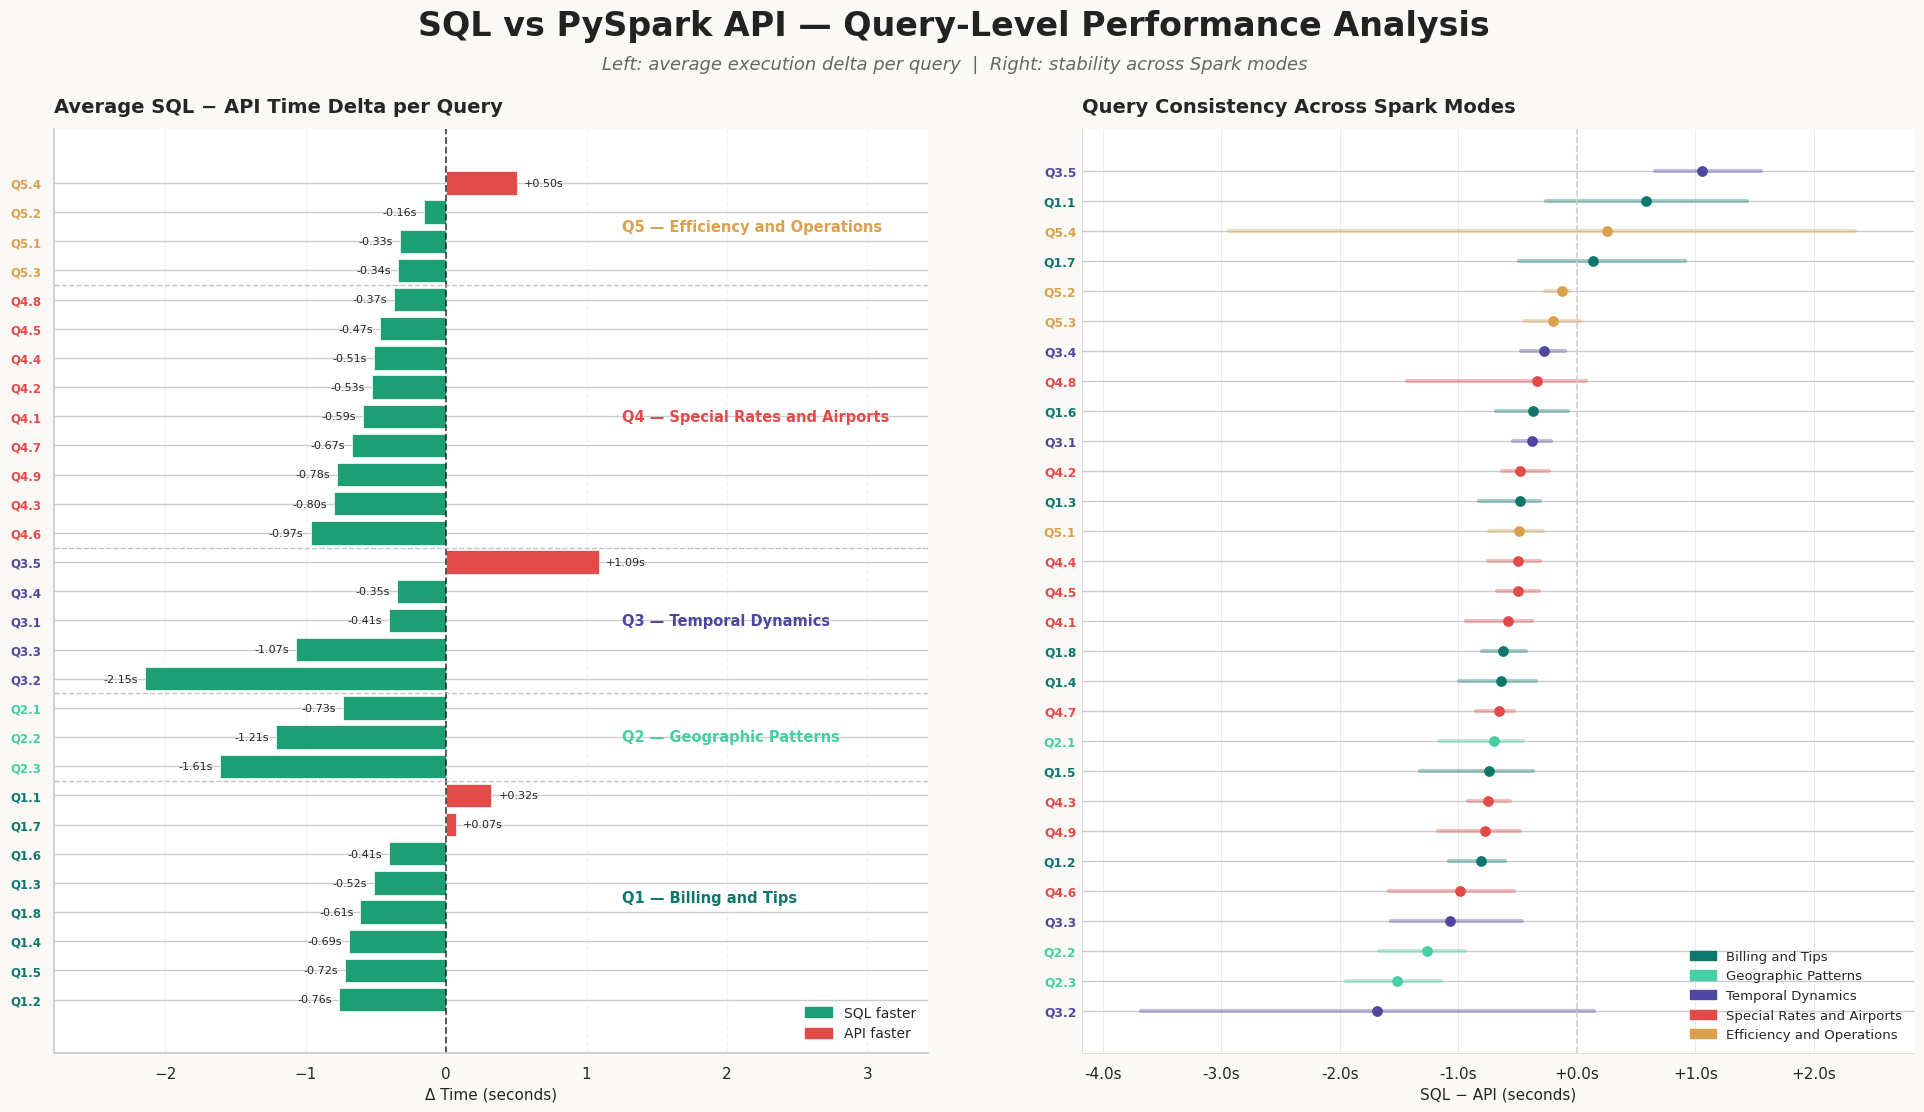

In [ ]:
# STYLE

sns.set_theme(style="whitegrid")

BG      = "#FAF9F6"
TEXT    = "#222222"
TEXT_M  = "#666666"
BORDER  = "#D3D1C7"

C_NEG = "#1D9E75"   # SQL faster
C_POS = "#E24B4A"   # API faster

CAT_NAMES = {
    "Q1": "Billing and Tips",
    "Q2": "Geographic Patterns",
    "Q3": "Temporal Dynamics",
    "Q4": "Special Rates and Airports",
    "Q5": "Efficiency and Operations",
}

CAT_COLORS = {
    "Q1": "#0f766e",
    "Q2": "#45CFA4",
    "Q3": "#4F479F",
    "Q4": "#E24B4A",
    "Q5": "#DBA04D",
}

SEC_COLORS = {
    "Billing and Tips":          "#0f766e",
    "Geographic Patterns":       "#45CFA4",
    "Temporal Dynamics":         "#4F479F",
    "Special Rates and Airports":"#E24B4A",
    "Efficiency and Operations": "#DBA04D",
}

# DATA PREP
df = df_queries.copy()

df["query_id"] = df["query_description"].str.extract(r"(Q\d+\.\d+)")
df["category"] = df["query_description"].str.extract(r"(Q\d)")

df["section_name"] = (
    df["category"]
    .map(CAT_NAMES)
)

df["time_delta_s"] = (
    df["sql_time_s"] -
    df["api_time_s"]
)

# PANEL 1 — DELTA PER QUERY
df_avg = (
    df.groupby(
        ["query_id", "category"],
        as_index=False
    )
    .agg(
        api_mean   = ("api_time_s", "mean"),
        api_std    = ("api_time_s", "std"),
        sql_mean   = ("sql_time_s", "mean"),
        sql_std    = ("sql_time_s", "std"),
        delta_mean = ("time_delta_s", "mean"),
    )
    .sort_values("query_id")
    .reset_index(drop=True)
)

df_avg["faster"] = np.where(
    df_avg["sql_mean"] < df_avg["api_mean"],
    "SQL",
    "API"
)

df_avg["speedup"] = (
    df_avg["api_mean"] /
    df_avg["sql_mean"]
)

df_delta = (
    df_avg.sort_values(
        ["category", "delta_mean"]
    )
    .reset_index(drop=True)
)

bar_colors = [
    C_NEG if d < 0 else C_POS
    for d in df_delta["delta_mean"]
]

# PANEL 2 — CONSISTENCY ACROSS SPARK MODES
q_mode = (
    df.groupby(
        ["query_description", "section_name", "spark_mode"],
        observed=True
    )
    .agg(
        median_delta=("time_delta_s", "median"),
        median_api  =("api_time_s", "median"),
        median_sql  =("sql_time_s", "median")
    )
    .reset_index()
)

q_consistency = (
    q_mode.groupby(
        ["query_description", "section_name"],
        observed=True
    )
    .agg(
        mean_delta = ("median_delta", "mean"),
        std_delta  = ("median_delta", "std"),
        min_delta  = ("median_delta", "min"),
        max_delta  = ("median_delta", "max"),
    )
    .reset_index()
    .assign(
        delta_range=lambda d:
        d["max_delta"] - d["min_delta"]
    )
    .sort_values("mean_delta")
)

# DASHBOARD LAYOUT
fig = plt.figure(
    figsize=(24, 12),
    facecolor=BG
)

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.05, 1],
    wspace=0.18
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

fig.suptitle(
    "SQL vs PySpark API — Query-Level Performance Analysis",
    fontsize=24,
    fontweight="bold",
    color=TEXT,
    y=0.98
)

fig.text(
    0.5,
    0.93,
    "Left: average execution delta per query  |  Right: stability across Spark modes",
    ha="center",
    fontsize=13,
    color=TEXT_M,
    style="italic"
)

# LEFT PANEL
bars = ax1.barh(
    range(len(df_delta)),
    df_delta["delta_mean"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.5
)

ax1.axvline(
    0,
    color="black",
    linewidth=1.3,
    linestyle="--",
    alpha=0.7
)

ax1.set_title(
    "Average SQL − API Time Delta per Query",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=12
)

ax1.set_xlabel(
    "Δ Time (seconds)",
    fontsize=11
)

ax1.set_yticks(range(len(df_delta)))
ax1.set_yticklabels(
    df_delta["query_id"],
    fontsize=8.5
)

for label, (_, row) in zip(
    ax1.get_yticklabels(),
    df_delta.iterrows()
):
    label.set_color(
        CAT_COLORS.get(
            row["category"],
            "black"
        )
    )
    label.set_fontweight("bold")

for cat, grp in df_delta.groupby("category", sort=True):

    start = grp.index[0]
    end   = grp.index[-1]

    if start > 0:
        ax1.axhline(
            start - 0.5,
            color="#aaa",
            linewidth=1.0,
            linestyle="--",
            alpha=0.7
        )

    mid = (start + end) / 2

    ax1.text(
        ax1.get_xlim()[1],
        mid,
        f"{cat} — {CAT_NAMES.get(cat, '')}",
        va="center",
        ha="left",
        fontsize=10.5,
        color=CAT_COLORS.get(cat, "black"),
        fontweight="bold"
    )

# value labels
for bar, val in zip(
    bars,
    df_delta["delta_mean"]
):

    offset = 0.05 if val >= 0 else -0.05
    ha     = "left" if val >= 0 else "right"

    ax1.text(
        val + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.2f}s",
        va="center",
        ha=ha,
        fontsize=8
    )

patch_sql = mpatches.Patch(
    color=C_NEG,
    label="SQL faster"
)

patch_api = mpatches.Patch(
    color=C_POS,
    label="API faster"
)

ax1.legend(
    handles=[patch_sql, patch_api],
    fontsize=10,
    frameon=False,
    loc="lower right"
)

x_max = abs(df_delta["delta_mean"]).max()

ax1.set_xlim(
    -(x_max * 1.3),
    x_max * 1.6
)

ax1.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# RIGHT PANEL
qc = q_consistency.reset_index(drop=True)
qc["query_id"] = (
    qc["query_description"]
    .str.extract(r"(Q\d+\.\d+)")[0]
)
qc["category"] = qc["query_id"].str.extract(r"(Q\d)")[0]

for i, row in qc.iterrows():

    sec  = row["section_name"]
    col  = SEC_COLORS.get(sec, TEXT_M)

    mean = row["mean_delta"]
    mn   = row["min_delta"]
    mx   = row["max_delta"]

    # range line
    ax2.plot(
        [mn, mx],
        [i, i],
        color=col,
        linewidth=3,
        alpha=0.35,
        zorder=2
    )

    # mean point
    ax2.scatter(
        [mean],
        [i],
        color=col,
        s=45,
        zorder=4
    )

ax2.axvline(
    0,
    color=BORDER,
    linewidth=1.2,
    linestyle="--"
)

short_labels = (
    qc["query_id"]
    .str.replace(
        r"^(Q\d+\.\d+):\s*",
        r"\1 ",
        regex=True
    )
)

ax2.set_yticks(np.arange(len(qc)))

ax2.set_yticklabels(
    short_labels,
    fontsize=8.8,
    color=SEC_COLORS.get(cat, "black"),
)

ax2.tick_params(
    axis="y",
    length=0,
    pad=4
)

ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda v, _: f"{v:+.1f}s"
    )
)

ax2.set_xlim(
    qc["min_delta"].min() - 0.5,
    qc["max_delta"].max() + 0.5
)

ax2.set_title(
    "Query Consistency Across Spark Modes",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=12
)

ax2.set_xlabel(
    "SQL − API (seconds)",
    fontsize=11
)

ax2.grid(
    axis="x",
    color=BORDER,
    linewidth=0.5,
    alpha=0.6
)

for sp in ax2.spines.values():
    sp.set_edgecolor(BORDER)
    sp.set_linewidth(0.5)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

for tick, (_, row) in zip(ax2.get_yticklabels(), qc.iterrows()):
    tick.set_color(CAT_COLORS.get(row["category"], "black"))
    tick.set_fontweight("bold")

handles = [
    mpatches.Patch(
        color=c,
        label=s
    )
    for s, c in SEC_COLORS.items()
]

ax2.legend(
    handles=handles,
    fontsize=9.5,
    frameon=False,
    loc="lower right",
    ncol=1
)

plt.show()

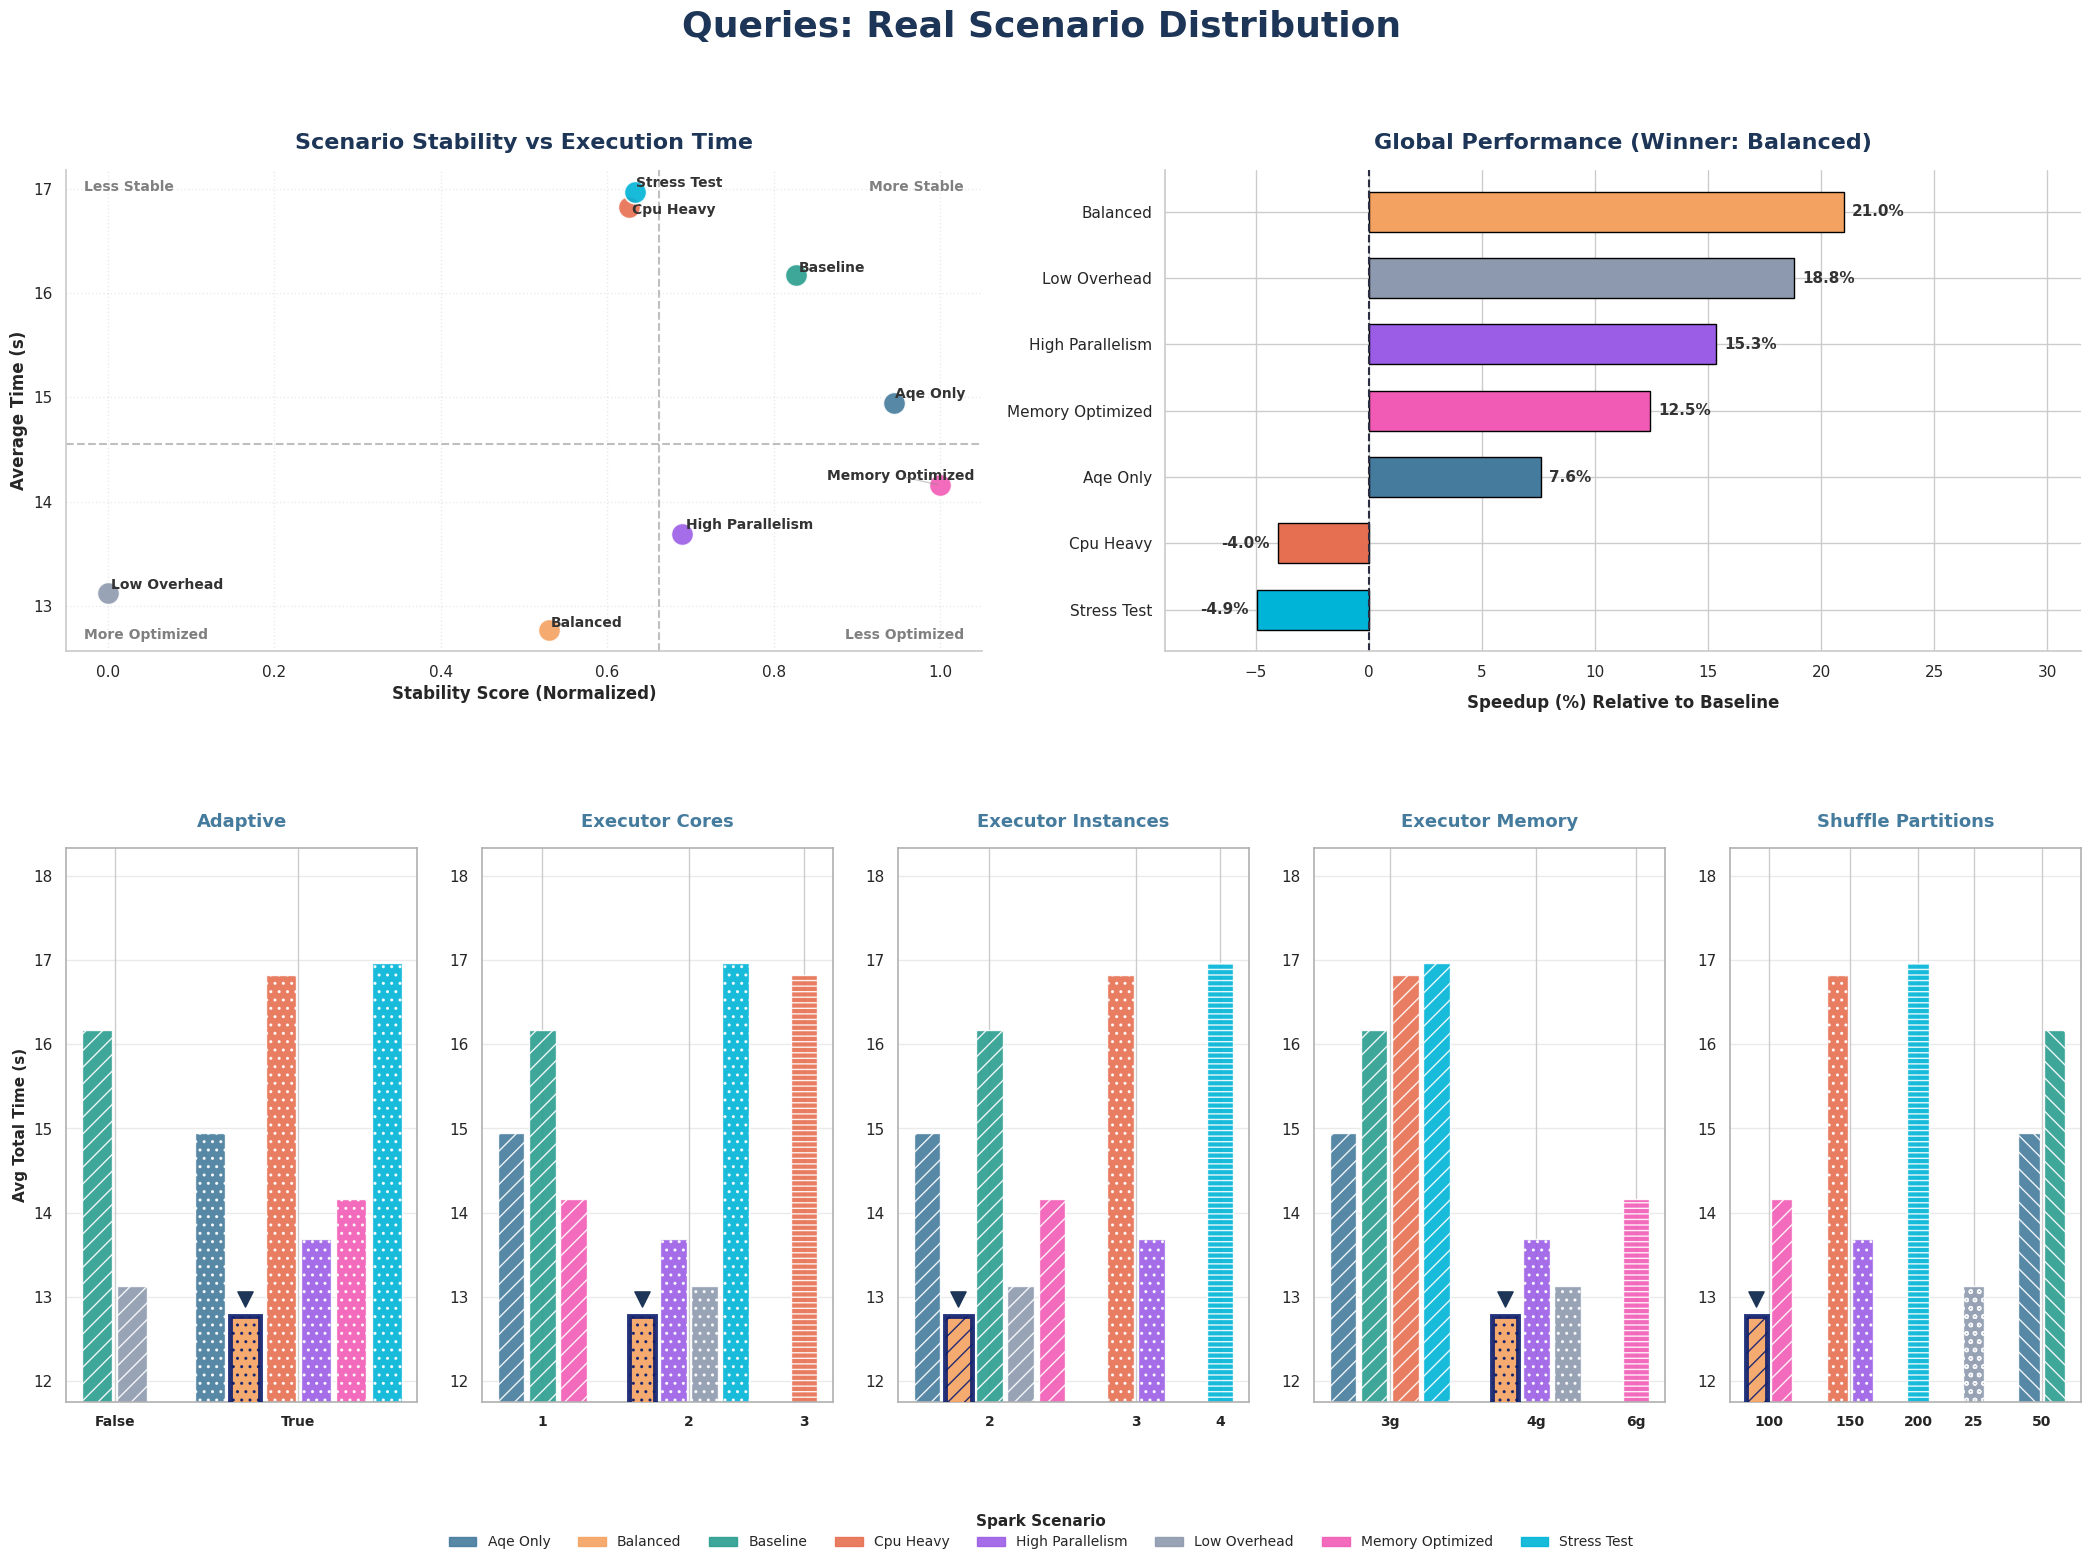

In [ ]:
# DATA PREPARATION
df_queries['query_id'] = df_queries['query_description'].apply(lambda x: x.split(':')[0].strip())
df_queries['section'] = df_queries['query_id'].apply(lambda x: x.split('.')[0].strip())

if 'total_time_s' not in df_queries.columns:
    df_queries['total_time_s'] = df_queries['sql_time_s'] + df_queries['api_time_s']

# GLOBAL PERFORMANCE
scenario_perf = df_queries.groupby('spark_mode')['total_time_s'].mean().reset_index()

baseline_time = scenario_perf[
    scenario_perf['spark_mode'] == 'baseline'
]['total_time_s'].values[0]

scenario_perf['improvement_pct'] = (
    (
        baseline_time -
        scenario_perf['total_time_s']
    )
    /
    baseline_time
) * 100

scenario_perf = scenario_perf[scenario_perf['spark_mode'] != 'baseline']

scenario_perf = scenario_perf.sort_values(by='improvement_pct',ascending=True)

best_scenario_name = (scenario_perf.iloc[-1]['spark_mode'])

best_config = df_queries[df_queries['spark_mode'] == best_scenario_name].iloc[0]

# STABILITY METRIC
stability_df = df_queries.groupby("spark_mode")["total_time_s"].agg(["mean", "std"]).reset_index()

stability_df["stability_score"] = 1 / (stability_df["std"] + 1e-6)

stability_df["stability_score_norm"] = (
    (stability_df["stability_score"] - stability_df["stability_score"].min()) /
    (stability_df["stability_score"].max() - stability_df["stability_score"].min())
)

# SCENARIO AGGREGATION
component_cols = [
    'adaptive',
    'executor_cores',
    'executor_instances',
    'executor_memory',
    'shuffle_partitions'
]

cols_to_group = ['spark_mode'] + component_cols

df_scenarios = df_queries.groupby(cols_to_group)['total_time_s'].mean().reset_index()

scenarios = sorted(df_scenarios['spark_mode'].unique())

feature_hatch_patterns = [
    '//',
    '..',
    '---',
    'oo',
    '\\\\'
]

global_min_time = (df_scenarios['total_time_s'].min())

# FIGURE LAYOUT
fig = plt.figure(figsize=(26, 16), facecolor=BG_COLOR)

fig.suptitle("Queries: Real Scenario Distribution", fontsize=26, fontweight='900', color='#1d3557', y=0.98)

gs_main = fig.add_gridspec(2, 1, height_ratios=[1, 1.15], hspace=0.38)

gs_top = gs_main[0].subgridspec(1, 2, wspace=0.20)

gs_bottom = gs_main[1].subgridspec(1, 10, wspace=0.45)

# Plot 1
ax_top = fig.add_subplot(gs_top[0, 0])

median_stab = stability_df["stability_score_norm"].median()
median_time = stability_df["mean"].median()

ax_top.axvline(median_stab, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax_top.axhline(median_time, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

texts = []
for _, row in stability_df.iterrows():
    scenario = row["spark_mode"]
    x = row["stability_score_norm"]
    y = row["mean"]

    ax_top.scatter(x, y, s=260, color=SCENARIO_COLORS.get(scenario, '#cccccc'),
                   edgecolor="white", linewidth=1.3, alpha=0.9, zorder=3)

    t = ax_top.text(x, y, scenario.replace("_", " ").title(),
                    fontsize=10, fontweight='bold', color='#333333')
    texts.append(t)

adjust_text(
    texts,
    ax=ax_top,
    arrowprops=dict(arrowstyle='-', color='gray', alpha=0.4),
    force_points=0.3,
    expand_text=(1.2, 1.2),
    expand_points=(1.2, 1.2)
)

ax_top.text(0.98, 0.98, "More Stable", transform=ax_top.transAxes, ha='right', va='top', fontsize=10, fontweight='bold', color='gray')
ax_top.text(0.02, 0.98, "Less Stable", transform=ax_top.transAxes, ha='left', va='top', fontsize=10, fontweight='bold', color='gray')
ax_top.text(0.02, 0.02, "More Optimized", transform=ax_top.transAxes, ha='left', va='bottom', fontsize=10, fontweight='bold', color='gray')
ax_top.text(0.98, 0.02, "Less Optimized", transform=ax_top.transAxes, ha='right', va='bottom', fontsize=10, fontweight='bold', color='gray')

ax_top.set_title("Scenario Stability vs Execution Time", fontsize=16, fontweight='900', color='#1d3557', pad=15)
ax_top.set_xlabel("Stability Score (Normalized)", fontsize=12, fontweight='bold')
ax_top.set_ylabel("Average Time (s)", fontsize=12, fontweight='bold')
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.grid(axis='both', linestyle=':', alpha=0.4)

# Plot 2
ax_perf = fig.add_subplot(gs_top[0, 1])

bar_colors = [
    SCENARIO_COLORS.get(mode, '#cccccc')
    for mode in scenario_perf['spark_mode']
]

bars = ax_perf.barh(scenario_perf['spark_mode'].str.replace('_', ' ').str.title(), scenario_perf['improvement_pct'],
                    color=bar_colors, edgecolor='black', height=0.6)

ax_perf.axvline(0, color='#2b2d42', linestyle='--', linewidth=1.5)

ax_perf.set_xlim(-9, scenario_perf['improvement_pct'].max() * 1.5)

ax_perf.bar_label(bars, fmt='%.1f%%', padding=6, fontweight='bold', fontsize=11, color='#333333')

ax_perf.set_title(
    f"Global Performance (Winner: {best_scenario_name.title()})", fontsize=16, color='#1d3557', fontweight='bold', pad=15
)

ax_perf.set_xlabel(
    "Speedup (%) Relative to Baseline", fontsize=12, fontweight='bold', labelpad=10
)

ax_perf.spines['top'].set_visible(False)
ax_perf.spines['right'].set_visible(False)

# Bottom plots
axes = [fig.add_subplot(gs_bottom[0, i*2:(i+1)*2]) for i in range(5)]

y_min = (df_scenarios['total_time_s'].min() * 0.92)

y_max = (df_scenarios['total_time_s'].max() * 1.08)

y_span = y_max - y_min

for ax, comp in zip(axes, component_cols):

    df_queries[comp] = (df_queries[comp].astype(str))

    df_scenarios[comp] = (df_scenarios[comp].astype(str))

    unique_vals = sorted(df_scenarios[comp].unique())

    pattern_mapping = dict(zip(unique_vals, feature_hatch_patterns))

    x_ticks = []
    x_labels = []
    current_x = 0

    for val in unique_vals:

        subset = df_scenarios[df_scenarios[comp] == val]
        group_start = current_x

        for _, row in subset.iterrows():

            scenario = row['spark_mode']

            bar_height = row['total_time_s']

            is_winner = (bar_height == global_min_time )

            bar_edge_color = ("#0B1D6E" if is_winner else 'white' )

            bar_line_width = (3.5 if is_winner else 1 )

            z_order = (10 if is_winner else 2 )

            ax.bar(current_x, bar_height, width=0.85, color=SCENARIO_COLORS.get(scenario, '#cccccc'), hatch=pattern_mapping[val], edgecolor=bar_edge_color, linewidth=bar_line_width, alpha=0.9, zorder=z_order )

            if is_winner:
                ax.scatter(current_x, bar_height + (y_span * 0.03), marker='v', color='#1d3557', s=120, zorder=20 )

            current_x += 1

        group_end = current_x - 1

        if len(subset) > 0:
            x_ticks.append((group_start + group_end) / 2)
            x_labels.append(str(val))

        current_x += 1.2

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10, fontweight='bold' )
    ax.set_title(comp.replace('_', ' ').title(), fontsize=13, fontweight='bold', pad=15, color='#457b9d')
    ax.set_ylim(y_min, y_max)
    ax.grid(axis='y', linestyle='-', alpha=0.4, zorder=0 )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#b0b0b0')
        spine.set_linewidth(1.2)

    if ax == axes[0]:
        ax.set_ylabel("Avg Total Time (s)", fontsize=11, fontweight='bold')
    else:
        ax.tick_params(axis='y', left=False)

handles = [
    mpatches.Patch( color=SCENARIO_COLORS.get(scen, '#cccccc'), label=scen.replace('_', ' ').title(), alpha=0.9)
    for scen in scenarios
]

fig.legend( handles=handles, title="Spark Scenario",
    title_fontproperties={
        'weight': 'bold',
        'size': 11
    }, loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=8, frameon=False, fontsize=10
)

plt.show()

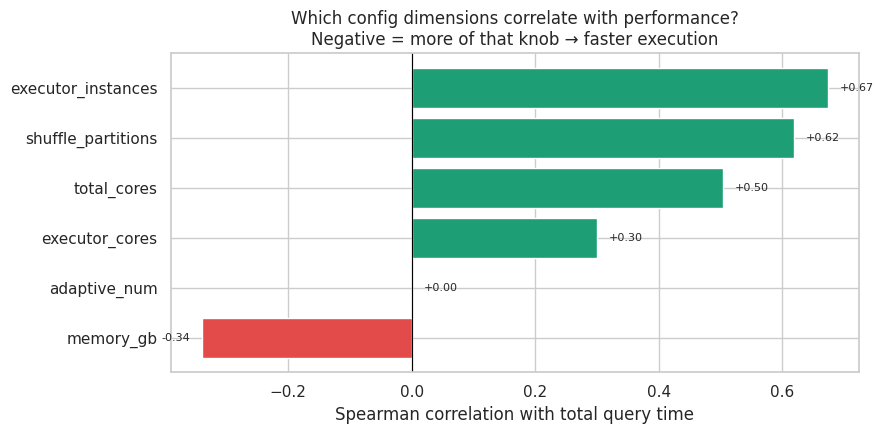


Full table:
         dimension    rho  p_value
         memory_gb -0.339    0.411
      adaptive_num  0.000    1.000
    executor_cores  0.300    0.470
       total_cores  0.503    0.204
shuffle_partitions  0.618    0.102
executor_instances  0.674    0.067


In [ ]:
totals = (
    df_queries.groupby("spark_mode")
              .agg(api_total=("api_time_s", "sum"),
                   sql_total=("sql_time_s", "sum"),
                   api_mean=("api_time_s", "mean"),
                   sql_mean=("sql_time_s", "mean"),
                   api_std=("api_time_s", "std"),
                   sql_std=("sql_time_s", "std"),
                   n_queries=("query_description", "count"))
              .reindex(present_scenarios)
)

corr_data = scenario_cfg.merge(totals[["api_total"]], left_index=True, right_index=True)
corr_data["adaptive_num"] = corr_data["adaptive"].astype(int)
corr_data["memory_gb"] = corr_data["executor_memory"].str.replace("g", "", regex=False).astype(float)

config_dims = ["executor_instances", "executor_cores", "memory_gb",
               "shuffle_partitions", "adaptive_num", "total_cores"]

correlations = []
for dim in config_dims:
    rho, pval = spearmanr(corr_data[dim], corr_data["api_total"])
    correlations.append({"dimension": dim, "rho": rho, "p_value": pval})
corr_df = pd.DataFrame(correlations).sort_values("rho")

fig, ax = plt.subplots(figsize=(9, 4.5))
colors_corr = ["#E24B4A" if r < 0 else "#1D9E75" for r in corr_df["rho"]]
ax.barh(corr_df["dimension"], corr_df["rho"], color=colors_corr, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman correlation with total query time")
ax.set_title("Which config dimensions correlate with performance?\n"
             "Negative = more of that knob → faster execution")
for i, (rho, p) in enumerate(zip(corr_df["rho"], corr_df["p_value"])):
    sig = " (p<0.05)" if p < 0.05 else ""
    ax.text(rho + (0.02 if rho >= 0 else -0.02), i,
            f"{rho:+.2f}{sig}", va="center",
            ha="left" if rho >= 0 else "right", fontsize=8)
plt.tight_layout(); plt.show()
print("\nFull table:")
print(corr_df.round(3).to_string(index=False))


# Models Analysis

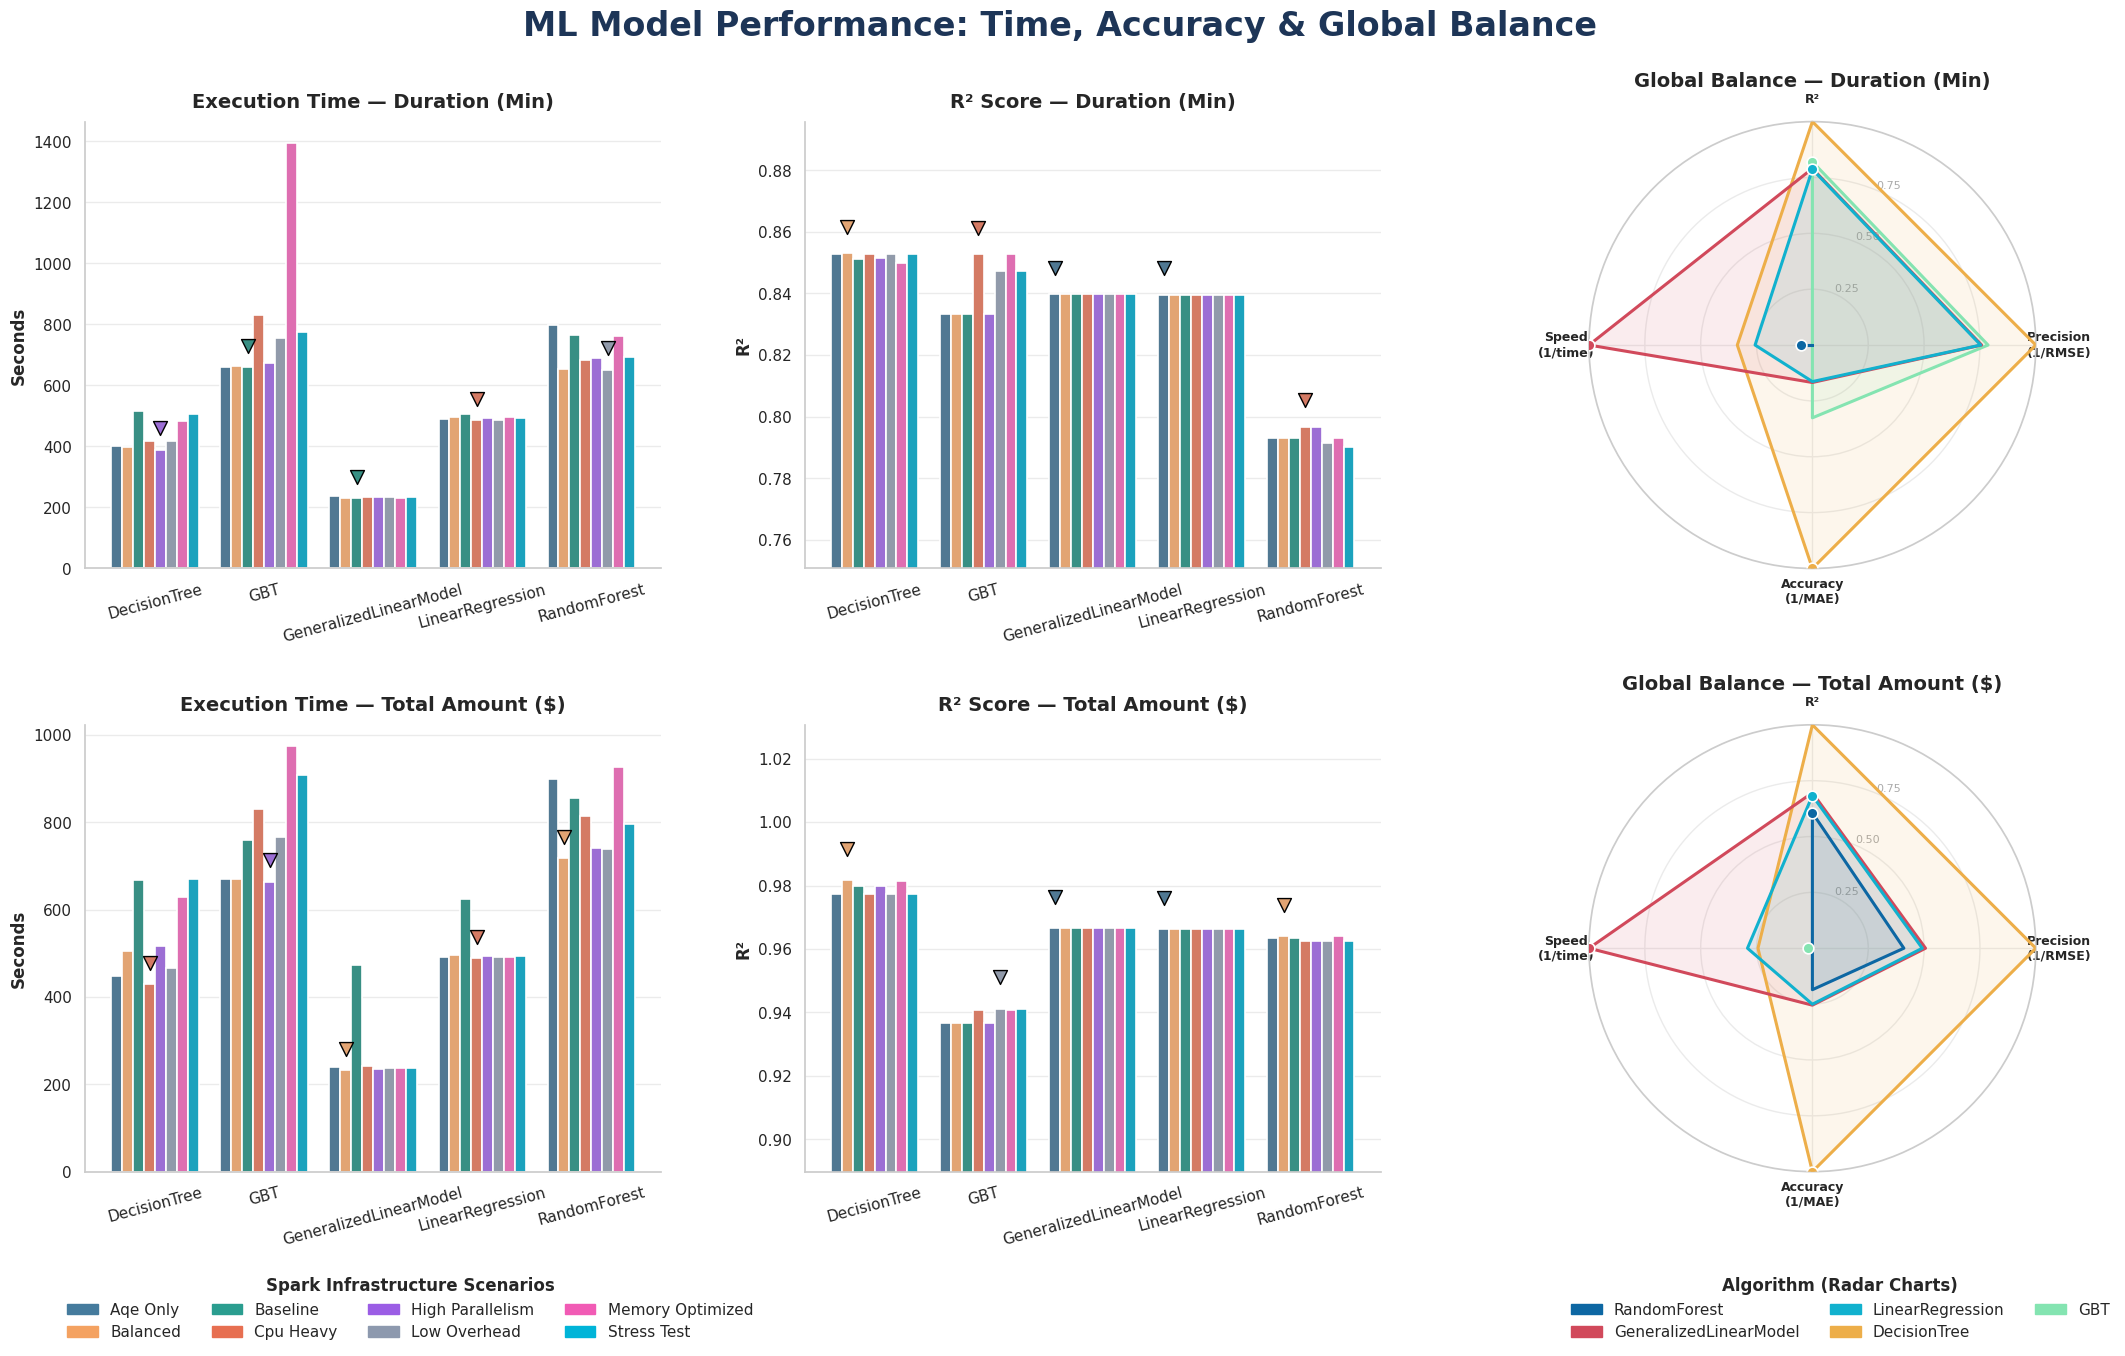

In [ ]:
# 1. Setup
BG_COLOR = "#ffffff"
sns.set_theme(style="whitegrid", rc={"grid.color": "#ebebeb", "axes.edgecolor": "#cccccc"})

RADAR_LABELS = ["R²", "Precision\n(1/RMSE)", "Accuracy\n(1/MAE)", "Speed\n(1/time)"]

# 2. Data Preparation
df = df_models[df_models['task_type'] == 'regression'].copy()

df['model_clean'] = df['model_name'].str.replace('Regressor', '').str.replace('_Ridge_Std', '')
df['target_clean'] = df['target'].replace({
    'total_amount': 'Total Amount ($)',
    'trip_duration_min': 'Duration (Min)'
})

targets = sorted(df["target_clean"].dropna().unique())

bar_df = df.groupby(["target_clean", "model_clean", "spark_mode"]).agg(
    mean_time=("execution_time_seconds", "mean"),
    mean_r2=("r2", "mean")
).reset_index()

radar_df = df.groupby(["target_clean", "model_clean"]).agg(
    r2_mean=("r2", "mean"),
    rmse_mean=("rmse", "mean"),
    mae_mean=("mae", "mean"),
    time_mean=("execution_time_seconds", "mean")
).reset_index()

def build_radar(sub):
    """Normaliza as métricas de 0 a 1 para o Radar Chart."""
    raw = {
        "R²": sub["r2_mean"].values.copy(),
        "Precision\n(1/RMSE)": 1.0 / sub["rmse_mean"].values,
        "Accuracy\n(1/MAE)": 1.0 / sub["mae_mean"].values,
        "Speed\n(1/time)": 1.0 / sub["time_mean"].values,
    }
    normed = {}
    for k, v in raw.items():
        mn, mx = v.min(), v.max()
        normed[k] = (v - mn) / (mx - mn + 1e-12)
    return normed

# 3. Dashboard Layout
fig = plt.figure(figsize=(26, 14), facecolor=BG_COLOR)
fig.suptitle("ML Model Performance: Time, Accuracy & Global Balance",
             fontsize=24, fontweight='900', color='#1d3557', y=0.98)

gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.25, top=0.90, bottom=0.15)

for i, target in enumerate(targets):

    t_bar = bar_df[bar_df["target_clean"] == target]
    t_rad = radar_df[radar_df["target_clean"] == target].reset_index(drop=True)

    ax_time = fig.add_subplot(gs[i, 0])
    ax_r2 = fig.add_subplot(gs[i, 1])
    ax_radar = fig.add_subplot(gs[i, 2], polar=True)

    sns.barplot(data=t_bar, x="model_clean", y="mean_time", hue="spark_mode",
                palette=SCENARIO_COLORS, edgecolor="white", linewidth=1.2, ax=ax_time)

    ax_time.set_title(f"Execution Time — {target}", fontsize=14, fontweight="bold", pad=10)
    ax_time.set_ylabel("Seconds", fontweight="bold")
    ax_time.set_xlabel("")
    ax_time.get_legend().remove()

    best_patches_time = {}
    for patch in ax_time.patches:
        h = patch.get_height()
        if pd.isna(h) or h == 0: continue
        model_idx = round(patch.get_x() + patch.get_width() / 2)
        if model_idx not in best_patches_time or h < best_patches_time[model_idx].get_height():
            best_patches_time[model_idx] = patch

    for patch in best_patches_time.values():
        x_c = patch.get_x() + patch.get_width() / 2
        ax_time.scatter(x_c, patch.get_height() + (t_bar['mean_time'].max() * 0.05), 
                        marker='v', color=patch.get_facecolor(), edgecolor='black', s=100, zorder=10)

    sns.barplot(data=t_bar, x="model_clean", y="mean_r2", hue="spark_mode",
                palette=SCENARIO_COLORS, edgecolor="white", linewidth=1.2, ax=ax_r2)

    ax_r2.set_title(f"R² Score — {target}", fontsize=14, fontweight="bold", pad=10)
    ax_r2.set_ylabel("R²", fontweight="bold")
    ax_r2.set_xlabel("")
    ax_r2.get_legend().remove()
    ax_r2.set_ylim(t_bar['mean_r2'].min() * 0.95, t_bar['mean_r2'].max() * 1.05)

    best_patches_r2 = {}
    for patch in ax_r2.patches:
        h = patch.get_height()
        if pd.isna(h) or h == 0: continue
        model_idx = round(patch.get_x() + patch.get_width() / 2)
        if model_idx not in best_patches_r2 or h > best_patches_r2[model_idx].get_height():
            best_patches_r2[model_idx] = patch

    for patch in best_patches_r2.values():
        x_c = patch.get_x() + patch.get_width() / 2
        ax_r2.scatter(x_c, patch.get_height() + (t_bar['mean_r2'].max() * 0.01), 
                      marker='v', color=patch.get_facecolor(), edgecolor='black', s=100, zorder=10)

    mnames = t_rad["model_clean"].tolist()
    normed = build_radar(t_rad)

    N = len(RADAR_LABELS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
    angles_c = np.append(angles, angles[0])
    vals_all = np.array(list(normed.values())).T

    ax_radar.set_theta_offset(np.pi / 2)
    ax_radar.set_theta_direction(-1)
    ax_radar.set_xticks(angles)
    ax_radar.set_xticklabels(RADAR_LABELS, fontsize=9, fontweight="bold")
    ax_radar.set_ylim(0, 1)
    ax_radar.set_yticks([0.25, 0.5, 0.75])
    ax_radar.set_yticklabels(["0.25", "0.50", "0.75"], fontsize=8, color="#aaaaaa")
    ax_radar.spines["polar"].set_color("#cccccc")

    ax_radar.set_title(f"Global Balance — {target}", fontsize=14, fontweight="bold", pad=25)

    for m, vals in zip(mnames, vals_all):
        v = np.append(vals, vals[0])
        clr = MODEL_COLORS.get(m, "#999999")
        ax_radar.plot(angles_c, v, color=clr, linewidth=2.2, zorder=3)
        ax_radar.fill(angles_c, v, color=clr, alpha=0.10, zorder=2)
        best_i = int(np.argmax(vals))
        ax_radar.scatter(angles[best_i], vals[best_i], s=60, color=clr,
                         edgecolors="white", linewidths=1.2, zorder=6)

    for ax in [ax_time, ax_r2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='x', rotation=15)

scen_handles = [mpatches.Patch(color=c, label=s.replace('_', ' ').title()) for s, c in SCENARIO_COLORS.items()]
leg1 = fig.legend(handles=scen_handles, loc="lower center", bbox_to_anchor=(0.25, 0.02),
                  ncol=4, frameon=False, fontsize=11, title="Spark Infrastructure Scenarios", title_fontproperties={'weight':'bold'})

mod_handles = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
leg2 = fig.legend(handles=mod_handles, loc="lower center", bbox_to_anchor=(0.80, 0.02),
                  ncol=3, frameon=False, fontsize=11, title="Algorithm (Radar Charts)", title_fontproperties={'weight':'bold'})

plt.show()

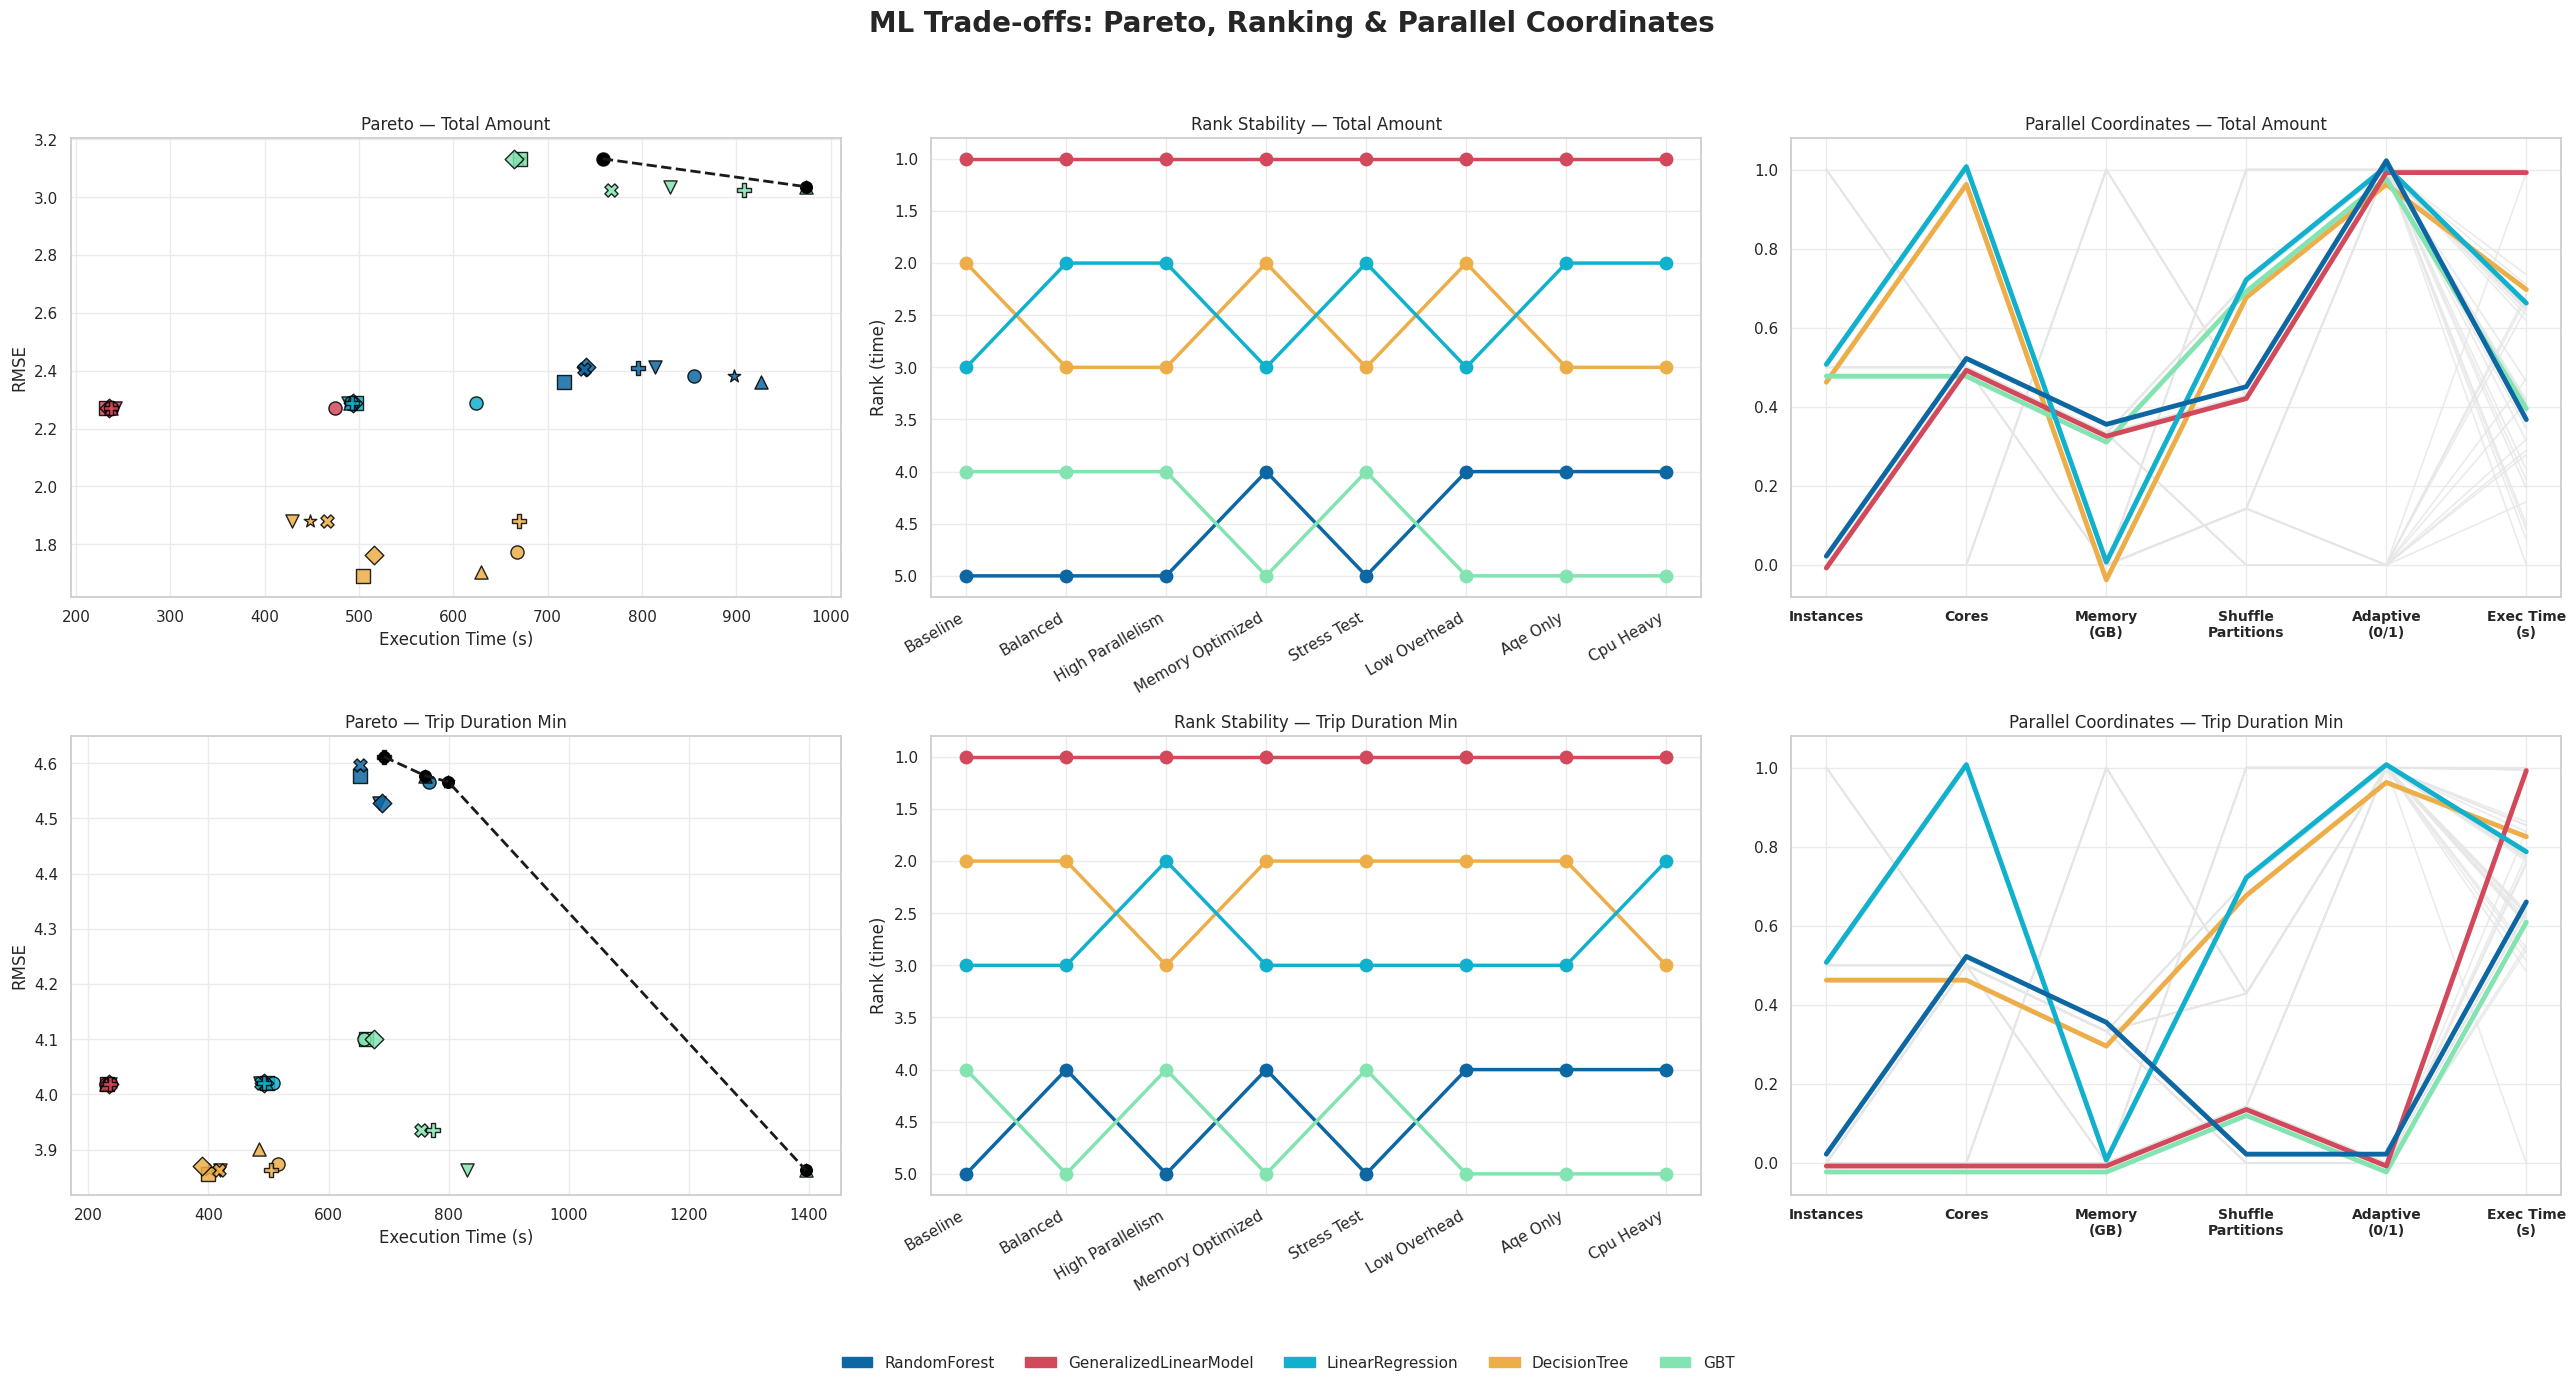

In [ ]:
sns.set_theme(style="whitegrid", rc={"grid.color": "#ebebeb"})

# DATA & COLORS
df = df_models.copy()

df["model_name"] = df["model_name"].str.replace("Regressor", "").str.replace('_Ridge_Std', '')

targets = ["total_amount", "trip_duration_min"]
models = df["model_name"].dropna().unique().tolist()
modes = df["spark_mode"].dropna().unique().tolist()

markers_pool = ["o", "s", "D", "^", "P", "X", "*", "v", "<", ">"]
SCENARIO_MARKERS = {s: markers_pool[i % len(markers_pool)] for i, s in enumerate(modes)}

# AGGREGATION
df["adaptive_int"] = df["adaptive"].astype(int)
df['memory_gb'] = df['executor_memory'].str.replace('g', '', regex=False).astype(float)

agg = df.groupby(["target", "model_name", "spark_mode"], as_index=False).agg(
    time=("execution_time_seconds", "mean"),
    rmse=("rmse", "mean"),
    executor_instances=("executor_instances", "mean"),
    executor_cores=("executor_cores", "mean"),
    memory_gb=("memory_gb", "mean"),
    shuffle_partitions=("shuffle_partitions", "mean"),
    adaptive_int=("adaptive_int", "mean")
)

# PARETO
def pareto_frontier(x, y):
    is_eff = np.ones(len(x), dtype=bool)
    for i, (xi, yi) in enumerate(zip(x, y)):
        if is_eff[i]:
            is_eff[is_eff] = ~(
                (x[is_eff] <= xi) &
                (y[is_eff] <= yi) &
                ((x[is_eff] < xi) | (y[is_eff] < yi))
            )
    return is_eff

# LAYOUT 2x3
fig, axes = plt.subplots(2, 3, figsize=(26, 14))
fig.suptitle(
    "ML Trade-offs: Pareto, Ranking & Parallel Coordinates",
    fontsize=20,
    fontweight="bold"
)

# PARALLEL COORDS HELP
PC_COLS = [
    "executor_instances",
    "executor_cores",
    "memory_gb",
    "shuffle_partitions",
    "adaptive_int",
    "time"
]

PC_LABELS = [
    "Instances",
    "Cores",
    "Memory\n(GB)",
    "Shuffle\nPartitions",
    "Adaptive\n(0/1)",
    "Exec Time\n(s)"
]

def norm_col(s, invert=False):
    mn, mx = s.min(), s.max()
    n = (s - mn) / (mx - mn + 1e-12)
    return 1 - n if invert else n

# LOOP TARGETS (ROWS)
for r, target in enumerate(targets):

    sub = agg[agg["target"] == target].copy()

    # 1) PARETO
    ax = axes[r, 0]

    x = sub["time"].values
    y = sub["rmse"].values

    mask = pareto_frontier(x, y)
    pareto = sub[mask].sort_values("time")

    for _, row in sub.iterrows():
        ax.scatter(
            row["time"], row["rmse"],
            color=MODEL_COLORS.get(row["model_name"], "#999"),
            marker=SCENARIO_MARKERS.get(row["spark_mode"], "o"),
            s=90,
            edgecolor="black",
            alpha=0.85
        )

    ax.plot(pareto["time"], pareto["rmse"], "k--", linewidth=2)
    ax.scatter(pareto["time"], pareto["rmse"], c="black", s=70)

    ax.set_title(f"Pareto — {target.replace('_', ' ').title()}")
    ax.set_xlabel("Execution Time (s)")
    ax.set_ylabel("RMSE")

    # 2) RANK CHART
    ax = axes[r, 1]

    sub["rank"] = sub.groupby("spark_mode")["time"].rank()

    for model in models:
        msub = sub[sub["model_name"] == model].sort_values("spark_mode")

        if msub.empty:
            continue

        xs = np.arange(len(msub))
        ys = msub["rank"].values

        ax.plot(xs, ys,
                color=MODEL_COLORS.get(model, "#999"),
                linewidth=2.5)

        ax.scatter(xs, ys,
                   color=MODEL_COLORS.get(model, "#999"),
                   s=80)

    ax.set_xticks(range(len(modes)))
    ax.set_xticklabels([m.replace('_', ' ').title() for m in modes], rotation=30, ha="right")
    ax.invert_yaxis()

    ax.set_title(f"Rank Stability — {target.replace('_', ' ').title()}")
    ax.set_ylabel("Rank (time)")

    # 3) PARALLEL COORDINATES (COM JITTER)
    ax = axes[r, 2]

    sub_pc = sub.copy()

    # normalize
    for col in PC_COLS:
        if col == "time":
            sub_pc[col] = norm_col(sub_pc[col], invert=True)
        else:
            sub_pc[col] = norm_col(sub_pc[col])

    xs = list(range(len(PC_COLS)))

    for _, row in sub_pc.iterrows():
        ys = [row[c] for c in PC_COLS]
        ax.plot(xs, ys,
                color="#e6e6e6",
                alpha=0.8,
                linewidth=1.2,
                zorder=1)

    best_idx = sub.groupby("model_name")["time"].idxmin()
    best = sub_pc.loc[best_idx].reset_index(drop=True)

    jitter_step = 0.015

    for i, row in best.iterrows():
        clr = MODEL_COLORS.get(row["model_name"], "#999")

        jitter = (i - len(best)/2) * jitter_step

        ys = [row[c] + jitter for c in PC_COLS]

        ax.plot(xs, ys,
                color=clr,
                linewidth=3.5,
                zorder=3)

    ax.set_xticks(xs)
    ax.set_xticklabels(PC_LABELS, fontsize=10, fontweight="bold")
    ax.set_ylim(-0.08, 1.08)

    ax.set_title(f"Parallel Coordinates — {target.replace('_', ' ').title()}")

# LEGEND
handles = [
    mpatches.Patch(color=c, label=m)
    for m, c in MODEL_COLORS.items()
]

fig.legend(handles=handles,
           loc="lower center",
           ncol=5,
           frameon=False,
           fontsize=11)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

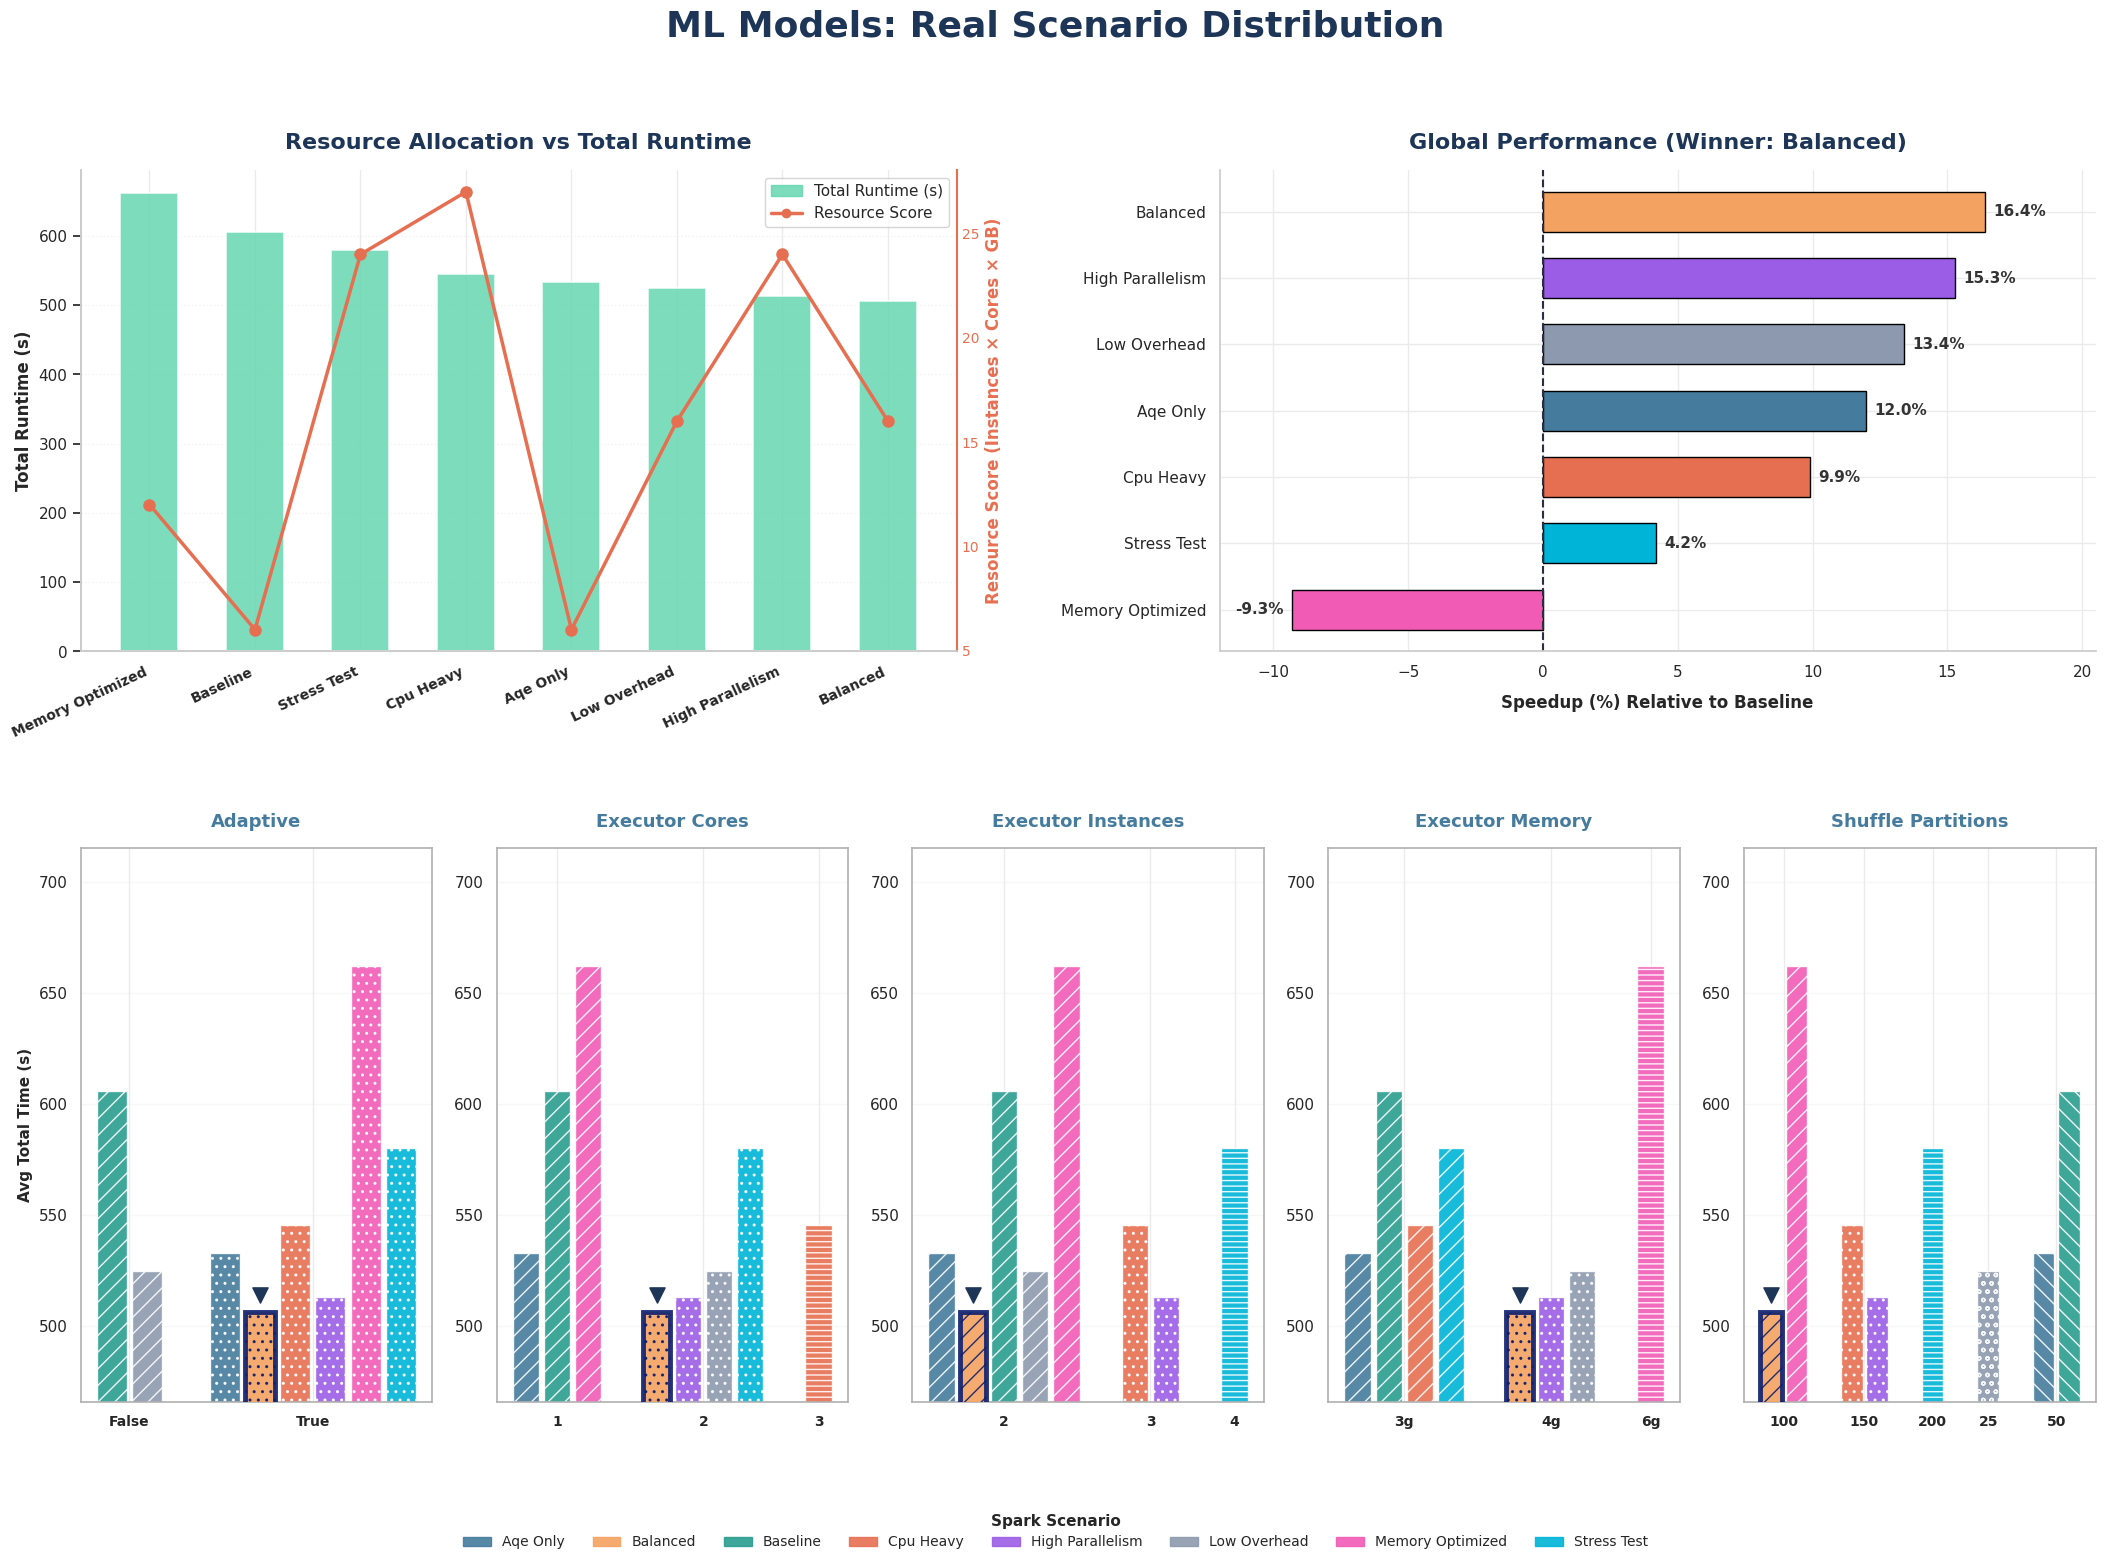

In [ ]:
# 1. SETUP
BG_COLOR = "#ffffff"
sns.set_theme(style="whitegrid", rc={"grid.color": "#ebebeb", "axes.edgecolor": "#cccccc"})

PURPLE = "#65d6b0"
CORAL = "#e76f51"

# 2. DATA PREPARATION
df_m = df_models[df_models['task_type'] == 'regression'].copy()
time_col = 'execution_time_seconds'

# Global performance
scenario_perf = (
    df_m.groupby('spark_mode')[time_col]
    .mean()
    .reset_index()
)

baseline_time = scenario_perf.loc[
    scenario_perf['spark_mode'] == 'baseline',
    time_col
].iloc[0]

scenario_perf['improvement_pct'] = (
    (baseline_time - scenario_perf[time_col]) / baseline_time
) * 100

scenario_perf = (
    scenario_perf[scenario_perf['spark_mode'] != 'baseline']
    .sort_values('improvement_pct')
)

best_scenario_name = scenario_perf.iloc[-1]['spark_mode']

df_m['memory_gb'] = (
    df_m['executor_memory']
    .astype(str)
    .str.lower()
    .str.replace('g', '', regex=False)
    .str.strip()
    .astype(float)
)

df_m['resource_score'] = (
    df_m['executor_instances']
    * df_m['executor_cores']
    * df_m['memory_gb']
)

config_check = (
    df_m.groupby('spark_mode')[[
        'executor_instances',
        'executor_cores',
        'executor_memory',
        'resource_score'
    ]]
    .nunique()
)

inconsistent = config_check[
    (config_check > 1).any(axis=1)
]

if not inconsistent.empty:
    print("\nWARNING: inconsistent resource configs detected:\n")
    print(inconsistent)

    print("\nDetailed configs:\n")
    print(
        df_m.groupby('spark_mode')[[
            'executor_instances',
            'executor_cores',
            'executor_memory',
            'resource_score'
        ]]
        .drop_duplicates()
    )

df_run = (
    df_m.groupby('spark_mode')
    .agg(
        total_time=(time_col, 'mean'),
        resource_score=('resource_score', 'first')
    )
    .reset_index()
    .sort_values(by='total_time', ascending=False)
)

component_cols = [
    'adaptive',
    'executor_cores',
    'executor_instances',
    'executor_memory',
    'shuffle_partitions'
]

cols_to_group = ['spark_mode'] + component_cols

df_scenarios = (
    df_m.groupby(cols_to_group)[time_col]
    .mean()
    .reset_index()
)

scenarios = sorted(df_scenarios['spark_mode'].unique())
feature_hatch_patterns = ['//', '..', '---', 'oo', '\\\\']
global_min_time = df_scenarios[time_col].min()

# 3. LAYOUT
fig = plt.figure(figsize=(26, 16), facecolor=BG_COLOR)
fig.suptitle("ML Models: Real Scenario Distribution", fontsize=26, fontweight='900', color='#1d3557', y=0.98)

gs_main = fig.add_gridspec(2, 1, height_ratios=[1, 1.15], hspace=0.38)
gs_top = gs_main[0].subgridspec(1, 2, wspace=0.30)
gs_bottom = gs_main[1].subgridspec(1, 10, wspace=0.45)

# PLOT 1: Resource Allocation vs Total Runtime (Dual Axis)
ax_res = fig.add_subplot(gs_top[0, 0])

x = np.arange(len(df_run))
xlabels = df_run['spark_mode'].str.replace('_', ' ').str.title().tolist()
total_times = df_run['total_time'].values
res_scores = df_run['resource_score'].values

ax_res.bar(x, total_times, width=0.55, color=PURPLE, alpha=0.85, zorder=3, edgecolor="white", linewidth=1.2)

ax2 = ax_res.twinx()
ax2.plot(x, res_scores, color=CORAL, linewidth=2.5, marker="o", markersize=8, zorder=5)

ax2.set_ylabel("Resource Score (Instances × Cores × GB)", color=CORAL, fontsize=12, fontweight='bold')
ax2.tick_params(axis="y", labelcolor=CORAL, labelsize=10, length=0)
ax2.spines["right"].set_edgecolor(CORAL)
ax2.spines["right"].set_linewidth(1.5)
ax2.spines["top"].set_visible(False)
ax2.grid(False)

ax_res.set_title("Resource Allocation vs Total Runtime", fontsize=16, fontweight='900', color='#1d3557', pad=15)
ax_res.set_ylabel("Total Runtime (s)", fontsize=12, fontweight='bold')
ax_res.set_xticks(x)
ax_res.set_xticklabels(xlabels, rotation=25, ha="right", fontsize=10, fontweight="bold")
ax_res.spines["top"].set_visible(False)
ax_res.grid(axis='y', linestyle=':', alpha=0.6)

handles_res = [
    mpatches.Patch(color=PURPLE, alpha=0.85, label="Total Runtime (s)"),
    Line2D([0], [0], color=CORAL, marker="o", linewidth=2.5, label="Resource Score"),
]
ax_res.legend(handles=handles_res, loc="upper right", fontsize=11, frameon=True)

# PLOT 2: Global Performance
ax_perf = fig.add_subplot(gs_top[0, 1])

bar_colors = [SCENARIO_COLORS.get(mode, '#cccccc') for mode in scenario_perf['spark_mode']]

bars = ax_perf.barh(scenario_perf['spark_mode'].str.replace('_', ' ').str.title(),
                    scenario_perf['improvement_pct'],
                    color=bar_colors, edgecolor='black', height=0.6)

ax_perf.axvline(0, color='#2b2d42', linestyle='--', linewidth=1.5)
ax_perf.set_xlim(-12,
                 scenario_perf['improvement_pct'].max() * 1.25)

ax_perf.bar_label(bars, fmt='%.1f%%', padding=6, fontweight='bold', fontsize=11, color='#333333')

ax_perf.set_title(f"Global Performance (Winner: {best_scenario_name.replace('_', ' ').title()})",
                  fontsize=16, color='#1d3557', fontweight='bold', pad=15)
ax_perf.set_xlabel("Speedup (%) Relative to Baseline", fontsize=12, fontweight='bold', labelpad=10)
ax_perf.spines['top'].set_visible(False)
ax_perf.spines['right'].set_visible(False)

# BOTTOM PLOTS: Parameter Breakdown
axes = [fig.add_subplot(gs_bottom[0, i*2:(i+1)*2]) for i in range(5)]

y_min = (df_scenarios[time_col].min() * 0.92)
y_max = (df_scenarios[time_col].max() * 1.08)
y_span = y_max - y_min

for ax, comp in zip(axes, component_cols):
    df_m[comp] = df_m[comp].astype(str)
    df_scenarios[comp] = df_scenarios[comp].astype(str)

    unique_vals = sorted(df_scenarios[comp].unique())
    pattern_mapping = dict(zip(unique_vals, feature_hatch_patterns))

    x_ticks = []
    x_labels = []
    current_x = 0

    for val in unique_vals:
        subset = df_scenarios[df_scenarios[comp] == val]
        group_start = current_x

        for _, row in subset.iterrows():
            scenario = row['spark_mode']
            bar_height = row[time_col]

            is_winner = (bar_height == global_min_time)
            bar_edge_color = ("#0B1D6E" if is_winner else 'white')
            bar_line_width = (3.5 if is_winner else 1)
            z_order = (10 if is_winner else 2)

            ax.bar(current_x, bar_height, width=0.85,
                   color=SCENARIO_COLORS.get(scenario, '#cccccc'),
                   hatch=pattern_mapping[val], edgecolor=bar_edge_color,
                   linewidth=bar_line_width, alpha=0.9, zorder=z_order)

            if is_winner:
                ax.scatter(current_x, bar_height + (y_span * 0.03),
                           marker='v', color='#1d3557', s=120, zorder=20)

            current_x += 1

        group_end = current_x - 1

        if len(subset) > 0:
            x_ticks.append((group_start + group_end) / 2)
            x_labels.append(str(val))

        current_x += 1.2

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10, fontweight='bold')
    ax.set_title(comp.replace('_', ' ').title(), fontsize=13, fontweight='bold', pad=15, color='#457b9d')
    ax.set_ylim(y_min, y_max)
    ax.grid(axis='y', linestyle='-', alpha=0.4, zorder=0)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#b0b0b0')
        spine.set_linewidth(1.2)

    if ax == axes[0]:
        ax.set_ylabel("Avg Total Time (s)", fontsize=11, fontweight='bold')
    else:
        ax.tick_params(axis='y', left=False)

# LEGEND
handles = [
    mpatches.Patch(color=SCENARIO_COLORS.get(scen, '#cccccc'),
                   label=scen.replace('_', ' ').title(), alpha=0.9)
    for scen in scenarios
]

fig.legend(
    handles=handles, title="Spark Scenario",
    title_fontproperties={'weight': 'bold', 'size': 11},
    loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=8, frameon=False, fontsize=10
)

plt.show()